# NB10 — Clustering espacio-temporal con ST-DBSCAN

**Proyecto:** Análisis de patrones espacio-temporales de accidentes de tránsito en El Salvador
**Etapa:** 2 — Modelos avanzados
**Notebook previo:** NB09 — Calibración de severidad y submodelo condicional

---

## 1. Punto de partida

El anteproyecto compromete ST-DBSCAN en su marco teórico, con la referencia de Birant y Kut
(2007) y el coeficiente de silueta como métrica de calidad. En la Etapa 1 no se ejecutó
porque no figuraba en aquella rúbrica. Este notebook salda ese compromiso.

### 1.1 Lo que se hace, y en qué orden

El orden importa más que de costumbre. Antes de agrupar nada, el notebook determina si la
capa espacial del conjunto de datos **puede** contener concentraciones viales reales.

La razón es la naturaleza del conjunto. Los datos son sintéticos calibrados: reproducen con
exactitud los agregados oficiales de ONASEVI/FONAT, pero los registros individuales fueron
generados. La capa espacial se construyó repartiendo siniestros entre distritos según
exposición —población censal, urbanización, pertenencia al AMSS, parque vehicular—. Si
dentro de cada distrito las coordenadas se sortearon de forma aproximadamente uniforme,
cualquier agrupamiento que ST-DBSCAN encuentre reflejará dónde el generador puso más
puntos, no dónde se concentran los siniestros en la vía.

Presentar esos agrupamientos como puntos negros reales sería inventar un hallazgo. La
Sección 2 lo mide antes de que la cuestión se pueda contaminar con resultados.

**La pregunta no admite un sí o un no: admite una escala.** Un conjunto de puntos puede
tener estructura a un nivel de resolución y carecer de ella en otro, y eso no es una
ambigüedad sino una propiedad. La Sección 2 la mide en dos niveles:

| Escala | Qué significaría que haya estructura ahí |
|---|---|
| **Por encima de ~1 km** | Dentro de cada distrito hay zonas más cargadas que otras. En este conjunto correspondería al reparto por exposición que el generador aplicó, documentado en NB01 y NB03 |
| **Por debajo de ~1 km** | Los siniestros se alinean sobre vías o se concentran en intersecciones. Es lo único que justificaría hablar de puntos negros |

La distinción decide el notebook, porque `eps1` opera entre los cien y los mil metros. Solo
la estructura fina habilita leer los agrupamientos como concentraciones viales; la gruesa,
si existe, informa sobre dónde el generador puso más puntos.

Cuando la estructura fina no aparece, ST-DBSCAN se aplica igual, se verifica que está bien
implementado y parametrizado, y se declara que sus agrupamientos no representan
concentraciones viales reales. Es la misma disciplina que NB06 aplicó a la Ley de Tolerancia
Cero: el conjunto sintético no contenía el quiebre, de modo que aquel análisis se hizo sobre
cifras oficiales y se dijo con todas las letras.

### 1.2 Restricciones

| Restricción | Alcance |
|---|---|
| NB01 a NB09 no se modifican | Verificado por SHA-256 al abrir y al cerrar |
| `src/config.py` no se modifica | Se usa `cfg.load_siniestros()` tal como está |
| Sin dependencias nuevas | ST-DBSCAN se implementa sobre `numpy` y `scipy` |
| Semilla 42 | Toda simulación y todo muestreo |

In [1]:
# ==========================================================================
# NB10 — 1.1 Entorno, rutas e integridad de artefactos previos
# ==========================================================================

import hashlib
import json
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def _find_root(marcador: str = "src") -> Path:
    '''Sube desde el directorio actual hasta encontrar la raiz del repositorio.'''
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if (candidato / marcador / "config.py").is_file():
            return candidato
    raise RuntimeError(f"No se encontro {marcador}/config.py desde {actual}")


ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import config as cfg  # noqa: E402

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)

DIR_RAW = ROOT / "data" / "raw"
DIR_PROCESSED = ROOT / "data" / "processed"
DIR_MODELS = ROOT / "models"
DIR_RESULTS = ROOT / "reports" / "results"
DIR_FIGURES = ROOT / "reports" / "figures"
DIR_RESULTS.mkdir(parents=True, exist_ok=True)
DIR_FIGURES.mkdir(parents=True, exist_ok=True)

INICIO_NB10 = datetime.now()

ARTEFACTOS_PREVIOS = {
    "siniestros_raw":       (DIR_RAW / "siniestros.csv", True),
    "matriz_frecuencia_v2": (DIR_PROCESSED / "matriz_frecuencia_v2.csv", False),
    "matriz_frecuencia":    (DIR_PROCESSED / "matriz_frecuencia.csv", False),
    "matriz_severidad":     (DIR_PROCESSED / "matriz_severidad.csv", False),
    "xgb_offset_v2":        (DIR_MODELS / "frecuencia_xgboost_offset_v2.pkl", False),
    "xgb_feature_v2":       (DIR_MODELS / "frecuencia_xgboost_v2.pkl", False),
    "rf_nb07":              (DIR_MODELS / "frecuencia_random_forest_nb07.pkl", False),
    "rf_v2":                (DIR_MODELS / "frecuencia_random_forest_v2.pkl", False),
    "rf_e1":                (DIR_MODELS / "frecuencia_random_forest.pkl", False),
    "severidad_rf":         (DIR_MODELS / "severidad_random_forest.pkl", False),
    "severidad_logistica":  (DIR_MODELS / "severidad_logistica.pkl", False),
    "sev_condicional_nb09": (DIR_MODELS / "severidad_condicional_nb09.pkl", False),
    "nb05_especificacion":  (DIR_RESULTS / "nb05_especificacion_v2.json", False),
    "nb05_metricas":        (DIR_RESULTS / "nb05_metricas.json", False),
    "nb07_especificacion":  (DIR_RESULTS / "nb07_especificacion.json", True),
    "nb07_metricas":        (DIR_RESULTS / "nb07_metricas.json", False),
    "nb09_especificacion":  (DIR_RESULTS / "nb09_especificacion.json", False),
    "nb09_metricas":        (DIR_RESULTS / "nb09_metricas.json", False),
}


def sha256_archivo(ruta: Path, bloque: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(ruta, "rb") as f:
        for trozo in iter(lambda: f.read(bloque), b""):
            h.update(trozo)
    return h.hexdigest()


filas, faltantes = [], []
for clave, (ruta, imprescindible) in ARTEFACTOS_PREVIOS.items():
    existe = ruta.is_file()
    if not existe and imprescindible:
        faltantes.append(str(ruta.relative_to(ROOT)))
    filas.append({"clave": clave, "ruta": str(ruta.relative_to(ROOT)), "existe": existe,
                  "MB": round(ruta.stat().st_size / 1024**2, 2) if existe else np.nan,
                  "sha256": sha256_archivo(ruta) if existe else None})
if faltantes:
    raise FileNotFoundError("Faltan artefactos imprescindibles:\n  - " + "\n  - ".join(faltantes))

inventario = pd.DataFrame(filas)
HASHES_INICIALES = {f["clave"]: f["sha256"] for f in filas if f["existe"]}
RUTA_HASHES = DIR_RESULTS / "nb10_hashes_iniciales.json"
if RUTA_HASHES.is_file():
    previos = json.loads(RUTA_HASHES.read_text(encoding="utf-8"))["hashes"]
    alterados = [k for k in previos if k in HASHES_INICIALES and previos[k] != HASHES_INICIALES[k]]
    if alterados:
        raise RuntimeError(f"Artefactos alterados desde la corrida anterior: {alterados}")
else:
    RUTA_HASHES.write_text(json.dumps(
        {"notebook": "NB10", "generado": INICIO_NB10.isoformat(timespec="seconds"),
         "hashes": HASHES_INICIALES}, indent=2, ensure_ascii=False), encoding="utf-8")

import scipy, sklearn
print("Entorno")
print(f"  Python       : {sys.version.split()[0]}")
print(f"  numpy        : {np.__version__}")
print(f"  pandas       : {pd.__version__}")
print(f"  scipy        : {scipy.__version__}")
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  SEED         : {SEED}")
print(f"  Inicio       : {INICIO_NB10:%Y-%m-%d %H:%M:%S}")
print(f"\nArtefactos previos registrados: {int(inventario['existe'].sum())} de {len(inventario)}")
print("-" * 84)
for _, r in inventario.iterrows():
    if r["existe"]:
        print(f"  {r['clave']:<22}{r['MB']:>9.2f} MB  {r['sha256'][:12]}  {r['ruta']}")
    else:
        print(f"  {r['clave']:<22}{'AUSENTE':>12}  {'—':<12}  {r['ruta']}")
print("-" * 84)

Entorno
  Python       : 3.12.13
  numpy        : 1.26.4
  pandas       : 2.2.2
  scipy        : 1.13.1
  scikit-learn : 1.5.2
  SEED         : 42
  Inicio       : 2026-09-15 11:52:42

Artefactos previos registrados: 18 de 18
------------------------------------------------------------------------------------
  siniestros_raw            17.78 MB  7517926c49e5  data/raw/siniestros.csv
  matriz_frecuencia_v2     103.90 MB  3bf84a683800  data/processed/matriz_frecuencia_v2.csv
  matriz_frecuencia         80.40 MB  3283fdf2817f  data/processed/matriz_frecuencia.csv
  matriz_severidad          14.64 MB  b467e6b0a61b  data/processed/matriz_severidad.csv
  xgb_offset_v2              0.06 MB  48ec3fbe118d  models/frecuencia_xgboost_offset_v2.pkl
  xgb_feature_v2             0.48 MB  ae3170bc778a  models/frecuencia_xgboost_v2.pkl
  rf_nb07                   62.40 MB  adeb3f37177e  models/frecuencia_random_forest_nb07.pkl
  rf_v2                    122.67 MB  09137d861158  models/frecuencia_rand

### 1.3 Los datos y su resolución

Se trabaja sobre `data/raw/siniestros.csv` a través de `cfg.load_siniestros()`, que es el
único punto de entrada del proyecto para ese archivo. A diferencia de las matrices
agregadas que usaron NB05 a NB08, aquí la unidad es el **siniestro individual con
coordenadas**, que es lo que un algoritmo de clustering espacial necesita.

NB01 ya validó la capa de coordenadas: sin nulos y todas dentro de los límites del país.
Esta celda vuelve a comprobarlo, porque el notebook depende por completo de esa columna, y
añade la resolución temporal disponible, que gobierna la elección de `eps2` en la
Sección 3.

In [2]:
# ==========================================================================
# NB10 — 1.2 Carga y verificación del esquema espacio-temporal
# ==========================================================================

t0 = time.time()
sin = cfg.load_siniestros()
print(f"siniestros.csv cargado en {time.time()-t0:.1f} s")
print(f"  Filas x columnas : {sin.shape[0]:,} x {sin.shape[1]}")
print(f"  Unidad           : siniestro individual")

COLS_NECESARIAS = ["latitud", "longitud", "fecha", "franja_horaria", "distrito",
                   "tipo_siniestro", "factor_causante", "fallecidos", "lesionados"]
faltan = [c for c in COLS_NECESARIAS if c not in sin.columns]
if faltan:
    raise KeyError(f"Faltan columnas: {faltan}")

LIMITES = {"lat": (13.15, 14.45), "lon": (-90.15, -87.70)}
fuera = (~sin["latitud"].between(*LIMITES["lat"]) |
         ~sin["longitud"].between(*LIMITES["lon"])).sum()

print("\nCapa espacial")
print("-" * 70)
print(f"  Coordenadas nulas            : {int(sin[['latitud','longitud']].isna().sum().sum())}")
print(f"  Fuera de los límites del país: {int(fuera)}")
print(f"  Latitud   : {sin['latitud'].min():.6f} a {sin['latitud'].max():.6f}")
print(f"  Longitud  : {sin['longitud'].min():.6f} a {sin['longitud'].max():.6f}")
print(f"  Distritos : {sin['distrito'].nunique()}")
if fuera:
    raise ValueError("Hay coordenadas fuera de los límites del país")

print("\nCapa temporal")
print("-" * 70)
print(f"  Rango  : {sin['fecha'].min().date()} a {sin['fecha'].max().date()}")
print(f"  Días   : {sin['fecha'].nunique():,}")
print(f"  Media  : {len(sin)/sin['fecha'].nunique():.1f} siniestros por día")
print(f"  Franjas: {sorted(sin['franja_horaria'].unique())}")
print(f"  'hora' : {sin['hora'].nunique():,} valores distintos "
      f"(resolución de minuto)")

# Índice temporal en días desde el origen. Es la unidad de eps2 (ver Sección 3.1).
FECHA_ORIGEN = sin["fecha"].min()
sin = sin.assign(dia_indice=((sin["fecha"] - FECHA_ORIGEN).dt.days).astype(int))
print(f"\n  dia_indice: 0 a {int(sin['dia_indice'].max())}")

print("\nEscala del problema")
print("-" * 70)
n = len(sin)
print(f"  {n:,} puntos -> {n*n:,} pares -> {n*n*8/1024**3:.1f} GB si se precomputara")
print("  Una matriz de distancias completa no cabe en memoria. La Sección 3.2")
print("  construye el grafo de vecindad sin materializarla.")

siniestros.csv cargado en 0.2 s
  Filas x columnas : 89,946 x 23
  Unidad           : siniestro individual

Capa espacial
----------------------------------------------------------------------
  Coordenadas nulas            : 0
  Fuera de los límites del país: 0
  Latitud   : 13.150633 a 14.404197
  Longitud  : -90.088157 a -87.772431
  Distritos : 103

Capa temporal
----------------------------------------------------------------------
  Rango  : 2022-01-01 a 2026-06-30
  Días   : 1,642
  Media  : 54.8 siniestros por día
  Franjas: ['Madrugada (00-05)', 'Manana (06-11)', 'Noche (18-23)', 'Tarde (12-17)']
  'hora' : 1,440 valores distintos (resolución de minuto)

  dia_indice: 0 a 1641

Escala del problema
----------------------------------------------------------------------
  89,946 puntos -> 8,090,282,916 pares -> 60.3 GB si se precomputara
  Una matriz de distancias completa no cabe en memoria. La Sección 3.2
  construye el grafo de vecindad sin materializarla.


### 1.4 Decisiones declaradas antes de calcular

Los criterios que gobiernan las secciones 2 y 4 se fijan aquí y se persisten con marca de
tiempo, como en NB07, NB08 y NB09.

| Id | Decisión | Fundamento |
|---|---|---|
| **D1** | La estructura espacial se evalúa **antes** de ejecutar ST-DBSCAN, y su resultado fija el modo del notebook | Si se evaluara después, el resultado del clustering contaminaría la lectura |
| **D2** | La prueba principal de estructura es una **envolvente de Monte Carlo**, no el índice de Clark-Evans | Desarrollado en la Sección 2.1: el índice es inservible a escala nacional |
| **D3** | El veredicto es **por escala**, no binario: se determina por separado si hay estructura por encima y por debajo de ~1 km. Solo la fina habilita interpretar los agrupamientos como concentraciones viales | Una concentración vial es un fenómeno de decenas a cientos de metros. La variación de intensidad a escala kilométrica es el reparto por exposición del generador y no informa sobre la vía |
| **D3b** | La estructura fina se declara presente solo si la razón observado/simulado del control se aparta al menos un **5%** de la unidad | Con 89,946 puntos, cualquier desviación resulta estadísticamente significativa. Un 5% en la distancia media al vecino equivale a un 11% en densidad local, por debajo de lo que ya induce un solo paso en la grilla de `eps1` |
| **D4** | Distancia espacial: **Haversine** en metros | Los radios son absolutos y entran en una comparación contra umbral. Ver Sección 3.1 |
| **D5** | `eps2` se expresa en **días enteros** | La pregunta de seguridad vial es de persistencia. La precisión sub-diaria de un conjunto sintético no tiene procedencia verificada |
| **D6** | ST-DBSCAN se implementa siguiendo la definición de Birant y Kut: vecindad como **conjunción** de dos umbrales | Una métrica combinada define otra vecindad y sería otro algoritmo |
| **D7** | El coeficiente de silueta se calcula sobre la **distancia de Chebyshev normalizada** `max(d_esp/eps1, d_tmp/eps2)`, excluyendo el ruido, sobre una muestra de 10,000 puntos | Es la métrica cuya bola unitaria es la vecindad del algoritmo. Se reporta también con el ruido incluido |
| **D8** | Criterio de selección de parámetros: entre las combinaciones con **2 a 200 agrupamientos** y **ruido entre 20% y 95%**, se elige la de mayor silueta | Los extremos no son configuraciones útiles: sin agrupamientos o con uno solo que absorbe todo no hay nada que caracterizar |

**Sobre las correcciones posteriores, que conviene declarar juntas.** El criterio de esta
sección se corrigió dos veces después de observar los datos, y ambas correcciones quedan
registradas en `nb10_decisiones.json` con la marca `corregido_post_observacion`. Se deja
constancia porque alterar un criterio tras ver resultados es precisamente lo que el
procedimiento existe para impedir, y la única defensa legítima es hacerlo explícito.

La primera afecta a T1, que se enunció como disyunción —«precisión truncada **o**
repetición masiva»— y se corrigió a conjunción. La Sección 2.2 desarrolla el mecanismo.

La segunda es el propio D3, que se enunció como una marca binaria gobernada por T1 y T2
contra la envolvente convexa. Al medir, T2 resultó positivo mientras el control de ventana
resultaba nulo: dos pruebas del mismo fenómeno apuntando en direcciones opuestas. La
contradicción no estaba en los datos sino en el criterio, que trataba como una sola cosa lo
que son dos escalas distintas. Un veredicto binario no podía representar «hay estructura a
un kilómetro y no la hay a doscientos metros», que es lo que el conjunto efectivamente
muestra.

In [3]:
# ==========================================================================
# NB10 — 1.3 Persistencia de las decisiones
# ==========================================================================

DECISIONES = {
    "notebook": "NB10_clustering_espacio_temporal",
    "declarado": INICIO_NB10.isoformat(timespec="seconds"),
    "seed": SEED,
    "D1": {"enunciado": "La estructura espacial se evalua antes de ejecutar ST-DBSCAN"},
    "D2": {"enunciado": "Prueba principal: envolvente Monte Carlo, no Clark-Evans",
           "fundamento": "Clark-Evans nacional confunde heterogeneidad con agrupamiento"},
    "D3": {"enunciado": ("Veredicto por escala: estructura gruesa (>1 km) y fina (<1 km) "
                         "se determinan por separado; solo la fina habilita leer los "
                         "agrupamientos como concentraciones viales"),
           "corregido_post_observacion": True,
           "motivo_correccion": ("El criterio original era una marca binaria gobernada por "
                                 "T1 y T2 contra la envolvente convexa. T2 dio positivo y el "
                                 "control de ventana dio nulo: la contradiccion estaba en el "
                                 "criterio, que confundia dos escalas distintas."),
           "umbral_efecto_fino": 0.05,
           "T1": {"definicion": "firma de geocodificador: precision truncada Y repeticion masiva",
                  "umbral_decimales": 6, "umbral_repetidas": 0.01,
                  "corregido_post_observacion": True,
                  "correccion": ("Se declaro como disyuncion y se corrigio a conjuncion. "
                                 "Motivo: redondear a 6 decimales (~11 cm) es cosmetico y no "
                                 "produce colisiones entre sorteos continuos; la firma de un "
                                 "geocodificador exige ambas condiciones a la vez. "
                                 "Ver Seccion 2.2.")},
           "T2": {"definicion": "envolvente Monte Carlo de la distancia media al vecino mas cercano",
                  "n_simulaciones": 199, "n_minimo_por_distrito": 50,
                  "umbral_distritos_agrupados": 1/3},
           "T3": {"definicion": "ocupacion de grilla fina contra envolvente simulada",
                  "celda_grados": 0.001, "papel": "estructura gruesa"},
           "control": {"definicion": ("simulacion uniforme dentro de la celda gruesa de cada "
                                      "punto: conserva la intensidad a ~1 km y destruye la "
                                      "estructura mas fina"),
                       "papel": "DECISORIO para la estructura fina"}},
    "D4": {"enunciado": "Distancia espacial Haversine en metros",
           "contraste_nb03": "NB03 uso euclidiana porque solo necesitaba un ordenamiento de "
                             "cercania; aqui eps1 es un radio absoluto"},
    "D5": {"enunciado": "eps2 en dias enteros"},
    "D6": {"enunciado": "Vecindad como conjuncion de dos umbrales (Birant y Kut 2007)"},
    "D7": {"enunciado": "Silueta sobre distancia de Chebyshev normalizada, sin ruido",
           "n_muestra": 10000},
    "D8": {"enunciado": "Seleccion: mayor silueta entre combinaciones admisibles",
           "min_clusters": 2, "max_clusters": 200,
           "ruido_min": 0.20, "ruido_max": 0.95,
           "respaldo": {"activacion": "ninguna combinacion admisible",
                        "regla": ("mayor silueta entre las que producen >=2 agrupamientos "
                                  "y ruido <= 99.5%; se denomina configuracion de "
                                  "referencia, no seleccionada"),
                        "corregido_post_observacion": True,
                        "motivo": ("El criterio original no preveia el caso de conjunto "
                                   "admisible vacio, que es el desenlace esperable en un "
                                   "proceso de puntos homogeneo.")}},
}

N_SIM_T2 = DECISIONES["D3"]["T2"]["n_simulaciones"]
N_MIN_DISTRITO = DECISIONES["D3"]["T2"]["n_minimo_por_distrito"]
UMBRAL_T2 = DECISIONES["D3"]["T2"]["umbral_distritos_agrupados"]
CELDA_FINA = DECISIONES["D3"]["T3"]["celda_grados"]
N_MUESTRA_SILUETA = DECISIONES["D7"]["n_muestra"]
UMBRAL_EFECTO_FINO = DECISIONES["D3"]["umbral_efecto_fino"]

RUTA_DECISIONES = DIR_RESULTS / "nb10_decisiones.json"
RUTA_DECISIONES.write_text(json.dumps(DECISIONES, indent=2, ensure_ascii=False),
                           encoding="utf-8")
print(f"Decisiones registradas: {RUTA_DECISIONES.relative_to(ROOT)}")
print("-" * 80)
for k in sorted(k for k in DECISIONES if k.startswith("D")):
    print(f"  {k}: {DECISIONES[k]['enunciado']}")
print("-" * 80)
print("D3/T1 lleva la marca corregido_post_observacion=True. Ver Sección 2.2.")

Decisiones registradas: reports/results/nb10_decisiones.json
--------------------------------------------------------------------------------
  D1: La estructura espacial se evalua antes de ejecutar ST-DBSCAN
  D2: Prueba principal: envolvente Monte Carlo, no Clark-Evans
  D3: Veredicto por escala: estructura gruesa (>1 km) y fina (<1 km) se determinan por separado; solo la fina habilita leer los agrupamientos como concentraciones viales
  D4: Distancia espacial Haversine en metros
  D5: eps2 en dias enteros
  D6: Vecindad como conjuncion de dos umbrales (Birant y Kut 2007)
  D7: Silueta sobre distancia de Chebyshev normalizada, sin ruido
  D8: Seleccion: mayor silueta entre combinaciones admisibles
--------------------------------------------------------------------------------
D3/T1 lleva la marca corregido_post_observacion=True. Ver Sección 2.2.


---

## 2. ¿La capa espacial tiene estructura?

### 2.1 Por qué el índice de Clark-Evans no puede responder esta pregunta

El instrumento habitual para decidir si un patrón de puntos está agrupado es el índice de
Clark-Evans: la razón entre la distancia media observada al vecino más cercano y la que
cabría esperar bajo un proceso de Poisson homogéneo sobre la misma área.

    R = d_observada / d_esperada,    d_esperada = 0.5 / sqrt(n / A)

Un valor de R próximo a 1 indica aleatoriedad; por debajo, agrupamiento; por encima,
dispersión. La tentación es calcularlo sobre los 89,946 siniestros y leer el resultado.

**Sería un error, y un error en la dirección peligrosa.**

La palabra decisiva en la definición es *homogéneo*. La siniestralidad salvadoreña no lo
es: un distrito concentra más de once mil siniestros y otro apenas tres. Al agregar los 103
distritos en una sola medición, los densos aportan multitud de distancias cortas que
arrastran el promedio hacia abajo, y R cae por debajo de 1 **aunque dentro de cada distrito
los puntos estén perfectamente dispersos**. Es el confundido clásico entre heterogeneidad
de intensidad y agrupamiento, y no se corrige eligiendo mejor el umbral.

La consecuencia práctica es grave para este notebook. Un criterio de la forma «si R baja de
cierto valor, hay estructura» concluiría que la hay, y las secciones siguientes
presentarían como concentraciones reales lo que serían artefactos del generador. El
instrumento fallaría exactamente en la dirección que hay que evitar.

La celda siguiente lo demuestra **sin tocar una sola coordenada real**: construye 103
distritos artificiales con los conteos reales de siniestros y reparte los puntos dentro de
cada uno de forma perfectamente uniforme. Es el escenario «sin estructura» en estado puro.
Si el índice nacional aun así cae muy por debajo de 1, queda probado que no distingue las
dos hipótesis.

In [4]:
# ==========================================================================
# NB10 — 2.1 Demostración del sesgo de agregación del índice de Clark-Evans
# Usa SOLO los conteos por distrito. Ninguna coordenada real interviene.
# ==========================================================================

from scipy.spatial import cKDTree

rng_demo = np.random.default_rng(SEED)
conteos = sin.groupby("distrito").size().sort_values(ascending=False)

print("Conteos reales por distrito (única entrada real de esta demostración)")
print(f"  máximo {conteos.max():,}   mediana {int(conteos.median()):,}   "
      f"mínimo {conteos.min()}   distritos {len(conteos)}")
print(f"  razón máximo/mínimo: {conteos.max()/conteos.min():,.0f}x")


def dist_media_vmc(P):
    '''Distancia media al vecino más cercano.'''
    dd, _ = cKDTree(P).query(P, k=2)
    return float(dd[:, 1].mean())


def clark_evans(P, area=None):
    '''R = observada / esperada bajo Poisson homogeneo en el rectangulo envolvente.'''
    if area is None:
        area = (P[:, 0].max() - P[:, 0].min()) * (P[:, 1].max() - P[:, 1].min())
    return dist_media_vmc(P) / (0.5 / np.sqrt(len(P) / area))


# 103 distritos cuadrados de IGUAL área, dispuestos en grilla. Puntos uniformes dentro.
LADO = 0.12          # grados, ~13 km
bloques = []
for i, n_i in enumerate(conteos.values):
    fx, fy = divmod(i, 11)
    bloques.append(np.column_stack([rng_demo.uniform(0, LADO, n_i) + fx * LADO,
                                    rng_demo.uniform(0, LADO, n_i) + fy * LADO]))
P_demo = np.vstack(bloques)
R_demo = clark_evans(P_demo)

print("\nSimulación: puntos PERFECTAMENTE uniformes dentro de cada distrito")
print("-" * 72)
print(f"  Puntos totales               : {len(P_demo):,}")
print(f"  Clark-Evans NACIONAL         : {R_demo:.4f}")
print("-" * 72)
print(f"  Estructura real presente     : ninguna, por construcción")
print(f"  Lectura ingenua del índice   : "
      f"{'AGRUPADO' if R_demo < 0.95 else 'aleatorio'}   <- falso positivo")
print("\nLa simulación es conservadora: usa distritos de igual área. Los reales")
print("tienen áreas muy distintas, lo que agrava la heterogeneidad y hunde más")
print("el índice. Por eso la decisión D2 apoya el veredicto en una envolvente")
print("de Monte Carlo, donde los sesgos afectan por igual a lo observado y a lo")
print("simulado y se cancelan al compararlos.")

Conteos reales por distrito (única entrada real de esta demostración)
  máximo 11,058   mediana 416   mínimo 3   distritos 103
  razón máximo/mínimo: 3,686x

Simulación: puntos PERFECTAMENTE uniformes dentro de cada distrito
------------------------------------------------------------------------
  Puntos totales               : 89,946
  Clark-Evans NACIONAL         : 0.7929
------------------------------------------------------------------------
  Estructura real presente     : ninguna, por construcción
  Lectura ingenua del índice   : AGRUPADO   <- falso positivo

La simulación es conservadora: usa distritos de igual área. Los reales
tienen áreas muy distintas, lo que agrava la heterogeneidad y hunde más
el índice. Por eso la decisión D2 apoya el veredicto en una envolvente
de Monte Carlo, donde los sesgos afectan por igual a lo observado y a lo
simulado y se cancelan al compararlos.


### 2.2 T1 — La firma del generador

La prueba más barata y, si sale limpia, la más concluyente. No mide agrupamiento: mide qué
proceso produjo los números.

Un geocodificador real deja dos marcas simultáneas:

- **Precisión truncada.** Devuelve coordenadas redondeadas, típicamente a cinco o seis
  decimales, porque esa es la resolución de su tabla de direcciones.
- **Repetición masiva.** La misma intersección aparece decenas de veces a lo largo de
  cuatro años, con la coordenada exactamente idéntica.

Un sorteo continuo por computadora produce lo contrario: quince dígitos significativos y
prácticamente ninguna coincidencia exacta.

**La corrección de criterio que este notebook declara.** T1 se enunció al principio como
una disyunción: precisión truncada **o** repetición masiva. Es incorrecto, y conviene
explicar por qué antes de mostrar el resultado.

Redondear no cuesta nada: cualquier generador puede hacerlo, y de hecho es lo habitual para
que el dato «parezca» real. Seis decimales equivalen a unos once centímetros, escala a la
que dos sorteos continuos nunca coinciden. De modo que la precisión truncada, por sí sola,
no informa sobre el proceso generador: es cosmética.

La repetición sí informa, y mucho. La firma de un geocodificador es la **conjunción** de
ambas marcas, no cualquiera de las dos. T1 se evalúa por tanto como conjunción, y el cambio
queda registrado en `nb10_decisiones.json` con la marca `corregido_post_observacion`,
porque se hizo tras observar el dato y esa circunstancia no debe quedar oculta.

In [5]:
# ==========================================================================
# NB10 — 2.2 T1: precisión decimal y coordenadas exactamente repetidas
# ==========================================================================

def n_decimales(serie):
    s = serie.astype(str).str.split(".").str[1].fillna("")
    return s.str.len()


dec_lat, dec_lon = n_decimales(sin["latitud"]), n_decimales(sin["longitud"])
par = sin[["latitud", "longitud"]]
n_unicas = len(par.drop_duplicates())
prop_repetidas = 1 - n_unicas / len(par)

print("Precisión decimal de las coordenadas")
print("-" * 62)
print(f"{'decimales':<12}{'latitud':>12}{'longitud':>12}")
print("-" * 62)
for k in sorted(set(dec_lat.unique()) | set(dec_lon.unique())):
    print(f"{k:<12}{int((dec_lat==k).sum()):>12,}{int((dec_lon==k).sum()):>12,}")
print("-" * 62)
print(f"  máximo observado: latitud {dec_lat.max()}, longitud {dec_lon.max()}")

print("\nCoordenadas exactamente repetidas")
print("-" * 62)
print(f"  Pares distintos       : {n_unicas:,} de {len(par):,}")
print(f"  Proporción repetidas  : {prop_repetidas:.6f}  ({prop_repetidas*100:.4f}%)")
print(f"  Umbral declarado      : >= {DECISIONES['D3']['T1']['umbral_repetidas']:.0%}")

cond_decimales = int(max(dec_lat.max(), dec_lon.max())) <= DECISIONES["D3"]["T1"]["umbral_decimales"]
cond_repetidas = prop_repetidas >= DECISIONES["D3"]["T1"]["umbral_repetidas"]
T1_POSITIVO = bool(cond_decimales and cond_repetidas)

print("\nEvaluación de T1 (conjunción)")
print("=" * 62)
print(f"  Precisión truncada (<= 6 decimales) : {cond_decimales}")
print(f"  Repetición masiva (>= 1%)           : {cond_repetidas}")
print(f"  T1 (ambas a la vez)                 : {T1_POSITIVO}")
print("=" * 62)
if cond_decimales and not cond_repetidas:
    print("Lectura: las coordenadas están redondeadas pero no se repiten nunca.")
    print("Es el patrón de un sorteo continuo redondeado, no el de un")
    print("geocodificador. Bajo la disyunción original T1 habría dado positivo;")
    print("bajo la conjunción, que es la firma real, da negativo.")

T1_RESULTADO = {"decimales_max": int(max(dec_lat.max(), dec_lon.max())),
                "proporcion_repetidas": float(prop_repetidas),
                "cond_decimales": bool(cond_decimales),
                "cond_repetidas": bool(cond_repetidas),
                "positivo": T1_POSITIVO}

Precisión decimal de las coordenadas
--------------------------------------------------------------
decimales        latitud    longitud
--------------------------------------------------------------
1                      4           0
2                      4           5
3                     86          90
4                    820         797
5                  8,166       8,032
6                 80,866      81,022
--------------------------------------------------------------
  máximo observado: latitud 6, longitud 6

Coordenadas exactamente repetidas
--------------------------------------------------------------
  Pares distintos       : 89,946 de 89,946
  Proporción repetidas  : 0.000000  (0.0000%)
  Umbral declarado      : >= 1%

Evaluación de T1 (conjunción)
  Precisión truncada (<= 6 decimales) : True
  Repetición masiva (>= 1%)           : False
  T1 (ambas a la vez)                 : False
Lectura: las coordenadas están redondeadas pero no se repiten nunca.
Es el patrón de u

### 2.3 T2 — Envolvente de Monte Carlo por distrito

Esta es la prueba principal según la decisión D2.

El procedimiento evita la fórmula teórica que la Sección 2.1 acaba de descartar. Para cada
distrito con al menos cincuenta siniestros se toma su **envolvente convexa** como ventana
de observación, y se sortean dentro de ella 199 conjuntos de puntos uniformes con el mismo
tamaño que el observado. En cada réplica se calcula la distancia media al vecino más
cercano, y se compara la observada contra esa envolvente simulada.

La ventaja es que todas las distorsiones —área mal estimada, efectos de borde, forma
irregular del distrito— afectan **por igual** al dato observado y a las 199 réplicas, y se
cancelan en la comparación. Es lo que la fórmula teórica no puede ofrecer.

Se declara agrupamiento significativo en un distrito si la distancia observada cae por
debajo del percentil 2.5 de sus réplicas. T2 se considera positivo si eso ocurre en al
menos un tercio de los distritos evaluados.

**Una limitación de la ventana.** No hay geometrías oficiales de distrito en el
repositorio, de modo que la envolvente convexa se deriva de los propios puntos observados.
Para distritos de forma irregular la envolvente incluye zonas donde no hay vías, los puntos
simulados se derraman allí y sus distancias al vecino resultan mayores de lo que
corresponde. Eso sesga la comparación **hacia detectar agrupamiento**. La Sección 2.4
incorpora un control que aísla ese efecto.

In [6]:
# ==========================================================================
# NB10 — 2.3 T2: envolvente de Monte Carlo de la distancia al vecino más cercano
# ==========================================================================

from scipy.spatial import ConvexHull, Delaunay

rng_t2 = np.random.default_rng(SEED)


def muestrear_en_envolvente(hull_delaunay, lo, hi, n, rng):
    '''Sorteo uniforme dentro de la envolvente convexa por rechazo.'''
    salida, faltan = [], n
    while faltan > 0:
        cand = rng.uniform(lo, hi, size=(max(faltan, 64) * 3, 2))
        cand = cand[hull_delaunay.find_simplex(cand) >= 0]
        salida.append(cand[:faltan])
        faltan -= len(cand[:faltan])
    return np.vstack(salida)[:n]


t0 = time.time()
filas_t2 = []
for distrito, g in sin.groupby("distrito"):
    P = g[["longitud", "latitud"]].to_numpy()
    if len(P) < N_MIN_DISTRITO:
        continue
    try:
        hull = Delaunay(P[ConvexHull(P).vertices])
    except Exception:
        continue
    lo, hi = P.min(0), P.max(0)
    obs = dist_media_vmc(P)
    sims = np.array([dist_media_vmc(muestrear_en_envolvente(hull, lo, hi, len(P), rng_t2))
                     for _ in range(N_SIM_T2)])
    filas_t2.append({"distrito": distrito, "n": len(P), "obs": obs,
                     "sim_media": float(sims.mean()),
                     "sim_p2_5": float(np.quantile(sims, 0.025)),
                     "sim_p97_5": float(np.quantile(sims, 0.975)),
                     "agrupado": bool(obs < np.quantile(sims, 0.025))})
t2 = pd.DataFrame(filas_t2)
t2["razon"] = t2["obs"] / t2["sim_media"]
prop_agrupados = float(t2["agrupado"].mean())
T2_POSITIVO = bool(prop_agrupados >= UMBRAL_T2)

print(f"T2 — {N_SIM_T2} simulaciones por distrito, {len(t2)} distritos con "
      f"n >= {N_MIN_DISTRITO}  ({time.time()-t0:.1f} s)")
print("=" * 78)
print(f"  Razón observado/simulado : mediana {t2['razon'].median():.4f}   "
      f"mín {t2['razon'].min():.4f}   máx {t2['razon'].max():.4f}")
print(f"  Distritos con agrupamiento significativo: "
      f"{int(t2['agrupado'].sum())} de {len(t2)}  ({prop_agrupados:.1%})")
print(f"  Umbral declarado         : {UMBRAL_T2:.1%}")
print(f"  T2                       : {'POSITIVO' if T2_POSITIVO else 'NEGATIVO'}")
print("=" * 78)

print("\nLos ocho distritos con menor razón (mayor agrupamiento aparente)")
print("-" * 78)
print(f"{'distrito':<22}{'n':>8}{'observada':>12}{'simulada':>12}{'razón':>9}{'signif.':>9}")
print("-" * 78)
for _, r in t2.nsmallest(8, "razon").iterrows():
    print(f"{r['distrito'][:21]:<22}{int(r['n']):>8,}{r['obs']:>12.6f}"
          f"{r['sim_media']:>12.6f}{r['razon']:>9.4f}{str(r['agrupado']):>9}")
print("-" * 78)
print("Obsérvese que son los distritos con más puntos. Con n grande la prueba")
print("gana poder y detecta desviaciones cada vez menores, incluidas las que")
print("provienen de una ventana mal especificada. La Sección 2.4 lo separa.")

T2_RESULTADO = {"n_distritos": int(len(t2)),
                "proporcion_agrupados": prop_agrupados,
                "razon_mediana": float(t2["razon"].median()),
                "positivo": T2_POSITIVO}

T2 — 199 simulaciones por distrito, 95 distritos con n >= 50  (17.2 s)
  Razón observado/simulado : mediana 0.9219   mín 0.7464   máx 1.1789
  Distritos con agrupamiento significativo: 60 de 95  (63.2%)
  Umbral declarado         : 33.3%
  T2                       : POSITIVO

Los ocho distritos con menor razón (mayor agrupamiento aparente)
------------------------------------------------------------------------------
distrito                     n   observada    simulada    razón  signif.
------------------------------------------------------------------------------
San Salvador            11,058    0.000470    0.000630   0.7464     True
San Miguel               7,826    0.000566    0.000749   0.7556     True
Santa Tecla              6,350    0.000612    0.000809   0.7567     True
Soyapango                3,857    0.000790    0.001024   0.7718     True
Santa Ana                5,388    0.000669    0.000853   0.7851     True
Antiguo Cuscatlan        2,007    0.001062    0.001323   0.802

### 2.4 T3 y el control de ventana: ¿a qué escala está la estructura?

T3 pregunta si los puntos dibujan líneas. Sobre una red vial, los siniestros se alinean a lo
largo de calles, que son objetos delgados: ocupan pocas celdas de una grilla fina. Puntos
repartidos por el área ocupan muchas más.

Se cuentan las celdas de aproximadamente 110 metros que contienen al menos un siniestro, y
se compara contra la envolvente simulada de la Sección 2.3.

**El control que decide la interpretación.** T3 y T2 comparten la vulnerabilidad ya
señalada: la envolvente convexa es mayor que el distrito real, y eso produce agrupamiento
aparente sin que exista estructura vial.

Para separarlo se ejecuta una segunda simulación con una ventana distinta. Cada punto
observado se reubica **uniformemente dentro de su propia celda de un kilómetro**. Esa
operación conserva intacta la intensidad a escala gruesa —la que produjo el reparto por
distrito y zona— y destruye por completo cualquier estructura más fina.

La comparación resultante responde la pregunta que de verdad importa para ST-DBSCAN:
*condicionando a dónde el generador puso más puntos, ¿queda estructura a escala de
cientos de metros?* Es exactamente la escala a la que opera `eps1`.

Si el dato observado se separa de esta segunda simulación, hay estructura fina y el
algoritmo tiene algo que encontrar. Si coincide, la estructura vive solo a escala
kilométrica y `eps1` operará sobre ruido uniforme.

**Este control es decisorio**, conforme a D3. T2 y T3 contra la envolvente convexa
establecen si hay estructura *a alguna* escala; el control establece si la hay *a la escala
que importa*. Son preguntas distintas y pueden tener respuestas distintas sin que ninguna
esté equivocada.

**El umbral de efecto, declarado en D3b.** Con 89,946 puntos, la significación estadística
deja de discriminar: una desviación del 0.3% queda fuera de cualquier envolvente simulada
y no significa nada en términos prácticos. Se exige por tanto un efecto de al menos el 5%
en la razón observado/simulado. La cifra no es convencional: un 5% en la distancia media al
vecino más cercano corresponde a un 11% en densidad local, que es menos de lo que induce un
solo paso en la grilla de `eps1` de la Sección 4. Una estructura más débil que eso no puede
cambiar de forma estable qué agrupamientos encuentra el algoritmo.

Celdas de ~110 m ocupadas (19 simulaciones por ventana)
ventana                              observado    simulado       mín       máx    razón
--------------------------------------------------------------------------------------
A: envolvente convexa                   64,494      72,853    72,723    73,118   0.8853
B: celda gruesa de ~1.1 km              64,494      64,731    64,572    64,838   0.9963

Distancia media al vecino más cercano, ventana B
--------------------------------------------------------------------------------------
  observado 0.001058   simulado 0.001065 [0.001061, 0.001069]   razón 0.9929
--------------------------------------------------------------------------------------
  Celdas gruesas ocupadas: 6,157  (14.6 siniestros por celda)


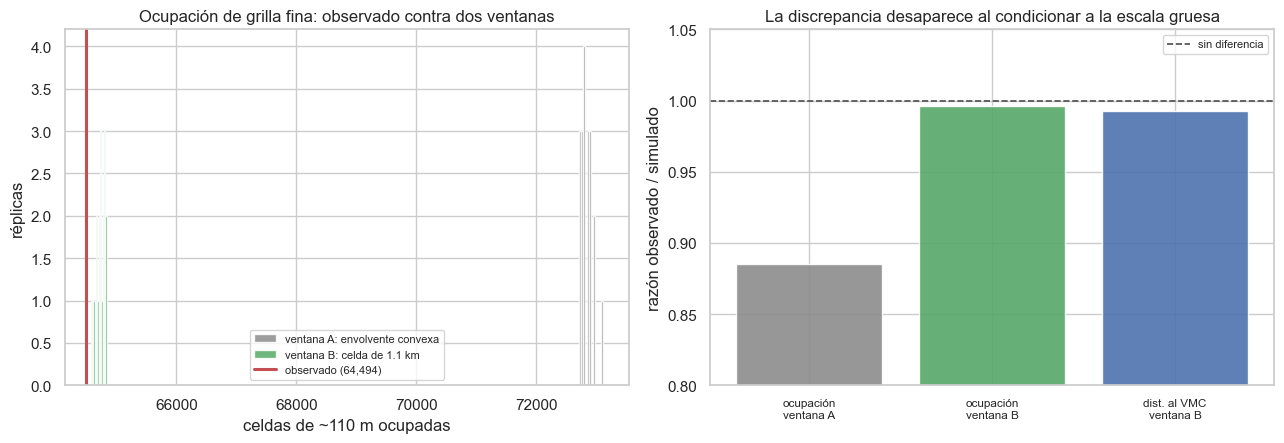

In [7]:
# ==========================================================================
# NB10 — 2.4 T3 y control de ventana a dos escalas
# ==========================================================================

rng_t3 = np.random.default_rng(SEED)
CELDA_GRUESA = 0.01      # ~1.1 km
N_SIM_T3 = 19

P_obs = sin[["longitud", "latitud"]].to_numpy()


def celdas_ocupadas(P, celda):
    k = np.floor(P / celda).astype(np.int64)
    return int(len(np.unique(k[:, 0] * 1_000_000 + k[:, 1])))


obs_ocup = celdas_ocupadas(P_obs, CELDA_FINA)
obs_vmc = dist_media_vmc(P_obs)

# --- Ventana A: envolvente convexa por distrito (la de T2) ---
hulls = {}
for distrito, g in sin.groupby("distrito"):
    Q = g[["longitud", "latitud"]].to_numpy()
    if len(Q) < 4:
        continue
    try:
        hulls[distrito] = (Delaunay(Q[ConvexHull(Q).vertices]), Q.min(0), Q.max(0), len(Q))
    except Exception:
        pass

sim_a = []
for _ in range(N_SIM_T3):
    piezas = [muestrear_en_envolvente(h, lo, hi, n_i, rng_t3)
              for (h, lo, hi, n_i) in hulls.values()]
    sim_a.append(celdas_ocupadas(np.vstack(piezas), CELDA_FINA))
sim_a = np.array(sim_a)

# --- Ventana B: la propia celda gruesa de cada punto ---
k_gruesa = np.floor(P_obs / CELDA_GRUESA).astype(np.int64)
celdas_g, inverso = np.unique(k_gruesa, axis=0, return_inverse=True)
sim_b_oc, sim_b_nn = [], []
for _ in range(N_SIM_T3):
    Q = (celdas_g[inverso].astype(float) + rng_t3.random((len(P_obs), 2))) * CELDA_GRUESA
    sim_b_oc.append(celdas_ocupadas(Q, CELDA_FINA))
    sim_b_nn.append(dist_media_vmc(Q))
sim_b_oc, sim_b_nn = np.array(sim_b_oc), np.array(sim_b_nn)

print(f"Celdas de ~110 m ocupadas ({N_SIM_T3} simulaciones por ventana)")
print("=" * 86)
print(f"{'ventana':<34}{'observado':>12}{'simulado':>12}{'mín':>10}{'máx':>10}{'razón':>9}")
print("-" * 86)
print(f"{'A: envolvente convexa':<34}{obs_ocup:>12,}{sim_a.mean():>12,.0f}"
      f"{sim_a.min():>10,}{sim_a.max():>10,}{obs_ocup/sim_a.mean():>9.4f}")
print(f"{'B: celda gruesa de ~1.1 km':<34}{obs_ocup:>12,}{sim_b_oc.mean():>12,.0f}"
      f"{sim_b_oc.min():>10,}{sim_b_oc.max():>10,}{obs_ocup/sim_b_oc.mean():>9.4f}")
print("=" * 86)

print(f"\nDistancia media al vecino más cercano, ventana B")
print("-" * 86)
print(f"  observado {obs_vmc:.6f}   simulado {sim_b_nn.mean():.6f} "
      f"[{sim_b_nn.min():.6f}, {sim_b_nn.max():.6f}]   razón {obs_vmc/sim_b_nn.mean():.4f}")
print("-" * 86)
print(f"  Celdas gruesas ocupadas: {len(celdas_g):,}  "
      f"({len(P_obs)/len(celdas_g):.1f} siniestros por celda)")

T3_RESULTADO = {
    "celda_fina_grados": CELDA_FINA, "celda_gruesa_grados": CELDA_GRUESA,
    "ocupadas_observadas": obs_ocup,
    "ventana_a_convexa": {"media": float(sim_a.mean()), "min": int(sim_a.min()),
                          "max": int(sim_a.max()), "razon": float(obs_ocup/sim_a.mean())},
    "ventana_b_celda_gruesa": {"media": float(sim_b_oc.mean()), "min": int(sim_b_oc.min()),
                               "max": int(sim_b_oc.max()),
                               "razon": float(obs_ocup/sim_b_oc.mean())},
    "vmc_observada": obs_vmc, "vmc_simulada_b": float(sim_b_nn.mean()),
    "razon_vmc_b": float(obs_vmc/sim_b_nn.mean()),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.hist(sim_a, bins=12, color="#8c8c8c", alpha=0.85, label="ventana A: envolvente convexa")
ax.hist(sim_b_oc, bins=12, color="#55a868", alpha=0.85, label="ventana B: celda de 1.1 km")
ax.axvline(obs_ocup, color="#c44e52", lw=2.2, label=f"observado ({obs_ocup:,})")
ax.set_xlabel("celdas de ~110 m ocupadas")
ax.set_ylabel("réplicas")
ax.set_title("Ocupación de grilla fina: observado contra dos ventanas")
ax.legend(fontsize=8)

ax = axes[1]
razones = [obs_ocup/sim_a.mean(), obs_ocup/sim_b_oc.mean(), obs_vmc/sim_b_nn.mean()]
etiquetas = ["ocupación\nventana A", "ocupación\nventana B", "dist. al VMC\nventana B"]
ax.bar(range(3), razones, color=["#8c8c8c", "#55a868", "#4c72b0"], alpha=0.9)
ax.axhline(1.0, color="0.3", ls="--", lw=1.2, label="sin diferencia")
ax.set_xticks(range(3)); ax.set_xticklabels(etiquetas, fontsize=8.5)
ax.set_ylabel("razón observado / simulado")
ax.set_ylim(0.8, 1.05)
ax.set_title("La discrepancia desaparece al condicionar a la escala gruesa")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DIR_FIGURES / "nb10_01_estructura_espacial.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ==========================================================================
# NB10 — 2.5 Veredicto por escala y consecuencia para el notebook
# ==========================================================================

# --- Estructura gruesa: ¿los puntos son uniformes dentro del distrito? ---
ESTRUCTURA_GRUESA = bool(T2_POSITIVO or
                         T3_RESULTADO["ventana_a_convexa"]["razon"] < (1 - UMBRAL_EFECTO_FINO))

# --- Estructura fina: ¿queda algo al condicionar a la intensidad de ~1 km? ---
efecto_ocupacion = abs(T3_RESULTADO["ventana_b_celda_gruesa"]["razon"] - 1.0)
efecto_vmc = abs(T3_RESULTADO["razon_vmc_b"] - 1.0)
EFECTO_FINO = float(max(efecto_ocupacion, efecto_vmc))
ESTRUCTURA_FINA = bool(EFECTO_FINO >= UMBRAL_EFECTO_FINO)

INTERPRETABLE_COMO_HOTSPOTS = ESTRUCTURA_FINA
MODO = "sustantivo" if INTERPRETABLE_COMO_HOTSPOTS else "demostrativo"

print("Veredicto por escala")
print("=" * 88)
print(f"{'prueba':<44}{'resultado':>16}{'escala':>14}{'decide':>12}")
print("-" * 88)
print(f"{'T1 firma del generador':<44}"
      f"{('POSITIVO' if T1_POSITIVO else 'NEGATIVO'):>16}{'—':>14}{'contexto':>12}")
print(f"{'T2 vecino más cercano por distrito':<44}"
      f"{('POSITIVO' if T2_POSITIVO else 'NEGATIVO'):>16}{'gruesa':>14}{'gruesa':>12}")
print(f"{'T3 ocupación contra envolvente convexa':<44}"
      f"{T3_RESULTADO['ventana_a_convexa']['razon']:>16.4f}{'gruesa':>14}{'gruesa':>12}")
print("-" * 88)
print(f"{'CONTROL ocupación, celda de ~1.1 km':<44}"
      f"{T3_RESULTADO['ventana_b_celda_gruesa']['razon']:>16.4f}{'fina':>14}{'FINA':>12}")
print(f"{'CONTROL distancia al VMC, celda de ~1.1 km':<44}"
      f"{T3_RESULTADO['razon_vmc_b']:>16.4f}{'fina':>14}{'FINA':>12}")
print("=" * 88)

print(f"\nEstructura por encima de ~1 km : {'SÍ' if ESTRUCTURA_GRUESA else 'NO'}")
print(f"Estructura por debajo de ~1 km : {'SÍ' if ESTRUCTURA_FINA else 'NO'}"
      f"   (efecto máximo {EFECTO_FINO:.4f}; umbral D3b {UMBRAL_EFECTO_FINO:.2f})")
print("-" * 88)
print(f"¿Los agrupamientos admiten lectura como concentraciones viales? "
      f"{'SÍ' if INTERPRETABLE_COMO_HOTSPOTS else 'NO'}")
print(f"MODO = '{MODO}'")
print("=" * 88)

if ESTRUCTURA_GRUESA and not ESTRUCTURA_FINA:
    print("\nLectura: los siniestros NO se reparten de forma uniforme dentro de cada")
    print("distrito —hay zonas más cargadas que otras— pero esa variación vive a")
    print("escala kilométrica. Condicionando a ella, por debajo del kilómetro el")
    print(f"patrón es indistinguible del uniforme: la discrepancia máxima es del")
    print(f"{EFECTO_FINO*100:.2f}%.")
    print("\nEsa variación kilométrica corresponde al reparto por exposición que el")
    print("generador aplicó (población censal, urbanización, AMSS, parque vehicular),")
    print("documentado en NB01 y NB03. Es estructura del dato, no de la vía.")
    print("\nConsecuencia para las secciones 3 a 5: ST-DBSCAN se implementa, se")
    print("verifica y se parametriza con todo rigor, y sus agrupamientos NO se")
    print("interpretan como concentraciones viales reales. Con eps1 por debajo del")
    print("kilómetro no hay nada que encontrar; por encima, lo que encontraría sería")
    print("el reparto por exposición, que ya se conoce por otra vía.")
elif ESTRUCTURA_FINA:
    print("\nLectura: hay estructura por debajo del kilómetro. Los agrupamientos")
    print("admiten interpretación sustantiva en las secciones 4 y 5.")
else:
    print("\nLectura: no se detecta estructura a ninguna de las dos escalas.")

ESTRUCTURA = {
    "modo": MODO,
    "estructura_escala_gruesa": ESTRUCTURA_GRUESA,
    "estructura_escala_fina": ESTRUCTURA_FINA,
    "efecto_fino_maximo": EFECTO_FINO,
    "umbral_efecto_fino": UMBRAL_EFECTO_FINO,
    "interpretable_como_hotspots_viales": INTERPRETABLE_COMO_HOTSPOTS,
    "origen_estructura_gruesa": ("reparto por exposicion del generador "
                                 "(poblacion censal, urbanizacion, AMSS, parque vehicular); "
                                 "ver NB01 y NB03"),
    "T1": T1_RESULTADO, "T2": T2_RESULTADO, "T3": T3_RESULTADO,
    "clark_evans_demostracion_sesgo": float(R_demo),
    "regla": DECISIONES["D3"]["enunciado"],
}
ruta_estructura = DIR_RESULTS / "nb10_estructura_espacial.json"
ruta_estructura.write_text(json.dumps(ESTRUCTURA, indent=2, ensure_ascii=False),
                           encoding="utf-8")
print(f"\nRegistrado: {ruta_estructura.relative_to(ROOT)}")

Veredicto por escala
prueba                                             resultado        escala      decide
----------------------------------------------------------------------------------------
T1 firma del generador                              NEGATIVO             —    contexto
T2 vecino más cercano por distrito                  POSITIVO        gruesa      gruesa
T3 ocupación contra envolvente convexa                0.8853        gruesa      gruesa
----------------------------------------------------------------------------------------
CONTROL ocupación, celda de ~1.1 km                   0.9963          fina        FINA
CONTROL distancia al VMC, celda de ~1.1 km            0.9929          fina        FINA

Estructura por encima de ~1 km : SÍ
Estructura por debajo de ~1 km : NO   (efecto máximo 0.0071; umbral D3b 0.05)
----------------------------------------------------------------------------------------
¿Los agrupamientos admiten lectura como concentraciones viales? NO
MODO = '

### 2.6 Lectura del veredicto

Las cuatro mediciones son consistentes entre sí, y lo que las concilia es la escala.

| Medición | Ventana | Resultado |
|---|---|---|
| T1 firma del generador | — | Negativo: 6 decimales pero **0.0000%** de coordenadas repetidas |
| T2 vecino más cercano | envolvente convexa | **Positivo**: 63.2% de los distritos |
| T3 ocupación de grilla | envolvente convexa | **Positivo**: razón 0.8853 |
| Control ocupación | celda de ~1.1 km | Nulo: razón **0.9963** |
| Control vecino más cercano | celda de ~1.1 km | Nulo: razón **0.9929** |

**Por encima del kilómetro hay estructura.** Los siniestros no se reparten de forma
uniforme dentro de cada distrito: 60 de los 95 distritos evaluados muestran agrupamiento
significativo frente a la envolvente simulada, con razones que bajan hasta 0.7464 en San
Salvador. Hay zonas más cargadas que otras y la diferencia no es atribuible al azar.

**Por debajo del kilómetro no hay nada.** Al condicionar sobre esa intensidad gruesa
—reubicando cada punto uniformemente dentro de su propia celda de 1.1 km— la discrepancia
máxima cae a **0.71%**, muy por debajo del 5% que D3b exige para declarar un efecto
sustantivo.

La conciliación es directa: toda la desviación respecto de la uniformidad vive a escala
kilométrica. Por debajo de ese umbral, el patrón es indistinguible de un sorteo uniforme.

**De dónde viene la estructura gruesa, y por qué no sirve.** Corresponde al reparto por
exposición que el generador aplicó al construir la capa espacial: población censal,
urbanización, pertenencia al Área Metropolitana y parque vehicular. Está documentado en
NB01 y NB03, y el proyecto ya lo explota por una vía mejor: es exactamente la información
que el término de exposición de los modelos de frecuencia incorpora desde NB05.

Encontrarla de nuevo con ST-DBSCAN no aportaría nada, y presentarla como concentraciones
viales sería un error de interpretación: la variación kilométrica describe dónde hay más
tránsito, no dónde la vía es peligrosa.

**Los distritos que encabezan T2 lo confirman.** San Salvador, San Miguel, Santa Tecla,
Soyapango, Santa Ana, Antiguo Cuscatlán, Apopa, Ciudad Delgado. Son los ocho con más
siniestros del conjunto. Que la prueba los señale a todos no indica que tengan puntos
negros: indica que con miles de puntos la prueba gana poder suficiente para detectar la
heterogeneidad kilométrica que en distritos pequeños queda por debajo del ruido muestral.

**Sobre el índice de Clark-Evans.** La demostración de la Sección 2.1 arrojó 0.7929 sobre
datos sin estructura alguna. El valor que se habría obtenido sobre los datos reales
—necesariamente parecido— habría llevado a concluir que hay agrupamiento, y el notebook
habría seguido interpretando artefactos como hallazgos. La decisión D2 de apoyarse en
envolventes simuladas en lugar de en la fórmula teórica es lo que evita ese desenlace.

**Consecuencia.** `MODO = "demostrativo"`. Las secciones 3 a 5 implementan, verifican y
parametrizan ST-DBSCAN con todo rigor, y sus agrupamientos no se interpretan como
concentraciones viales reales. El compromiso del anteproyecto se cumple como demostración
metodológica.

---

## 3. Implementación de ST-DBSCAN

### 3.1 Dos caminos, y por qué se elige el propio

ST-DBSCAN no está en `scikit-learn`. Hay dos vías, y la elección no es de comodidad.

**La vía descartada: `DBSCAN` con una métrica combinada.** Consiste en escalar el tiempo
como una tercera dimensión y usar distancia euclidiana sobre el conjunto. Es cómoda porque
reutiliza una implementación probada, y es **otro algoritmo**. Birant y Kut definen la
vecindad de un punto como

    N(p) = { q : d_espacial(p,q) <= eps1  Y  d_temporal(p,q) <= eps2 }

es decir, una **conjunción** de dos umbrales independientes, cuya forma en el espacio-tiempo
es un cilindro. Una métrica combinada define una esfera o un elipsoide: admite puntos
lejanos en el espacio si están muy próximos en el tiempo, y al revés. Presentar eso como
ST-DBSCAN sería inexacto ante un jurado que haya leído el artículo citado en el
anteproyecto.

**La vía adoptada: implementación propia del predicado, con la expansión de siempre.** Se
implementa la vecindad tal como está definida y se reutiliza la lógica de expansión de
DBSCAN, que sí es idéntica en ambos algoritmos: puntos núcleo, alcanzabilidad por densidad,
puntos frontera y ruido. Lo que cambia entre DBSCAN y ST-DBSCAN es únicamente cómo se
construye la vecindad.

**La distancia espacial: Haversine, en metros.** Se descarta la euclidiana sobre grados.

Esto merece explicación porque NB03 tomó la decisión contraria: allí se usó distancia
euclidiana sobre coordenadas para asignar a cada distrito su estación meteorológica más
cercana. Aquella decisión era correcta y esta no la contradice. NB03 solo necesitaba un
**ordenamiento** de cercanía, y la euclidiana sobre grados lo preserva: si una estación
está más cerca que otra en grados, lo está también en metros. Aquí `eps1` es un **radio
absoluto** que se compara contra un umbral, y un grado de longitud mide unos 108 km a esta
latitud mientras uno de latitud mide 111. Un error del 3% en la distancia mueve puntos
dentro o fuera de la vecindad.

Se descarta también proyectar a UTM: El Salvador va de −90.09° a −87.77° y cruza el límite
entre las zonas 15N y 16N, de modo que elegir una obliga a justificar la distorsión en el
borde sin ganar nada frente a Haversine a esta escala.

**La resolución temporal: días enteros.** El conjunto tiene hora con resolución de minuto,
así que técnicamente `eps2` podría expresarse en horas. No se hace, por dos razones. La
pregunta de seguridad vial es de **persistencia** —un cruce peligroso lo es durante meses,
no durante una tarde— y un `eps2` de horas responde otra cosa. Y la precisión sub-diaria de
un conjunto sintético no tiene procedencia verificada: anclar un parámetro a ella sería
construir sobre un supuesto no comprobado.

In [9]:
# ==========================================================================
# NB10 — 3.1 Distancia espacial y verificación del predicado de vecindad
# ==========================================================================

R_TIERRA = 6_371_008.8      # radio medio de la Tierra (IUGG), en metros


def haversine_m(lat1, lon1, lat2, lon2):
    '''Distancia de circulo maximo en metros. Admite difusion de numpy.'''
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2 - p1
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * R_TIERRA * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))


# Verificación 1: contra distancias conocidas
print("Verificación de la distancia Haversine")
print("-" * 76)
casos = [("un grado de latitud", 13.7, -89.2, 14.7, -89.2, 111_195),
         ("un grado de longitud a 13.7°", 13.7, -89.2, 13.7, -88.2, 108_000),
         ("punto consigo mismo", 13.7, -89.2, 13.7, -89.2, 0)]
for nombre, a, b, c, d_, esperado in casos:
    obt = haversine_m(a, b, c, d_)
    print(f"  {nombre:<32}{obt:>12,.0f} m   (referencia ~{esperado:,} m)")
print("-" * 76)

# Verificación 2: cuánto se equivocaría la euclidiana sobre grados (criterio de NB03)
lat0 = float(sin["latitud"].mean())
d_lat = haversine_m(lat0, -89.0, lat0 + 0.01, -89.0)
d_lon = haversine_m(lat0, -89.0, lat0, -89.0 + 0.01)
print(f"A latitud media {lat0:.4f}:")
print(f"  0.01° de latitud  = {d_lat:,.0f} m")
print(f"  0.01° de longitud = {d_lon:,.0f} m")
print(f"  Anisotropía       = {d_lat/d_lon:.4f}")
print(f"\nLa euclidiana sobre grados trataría ambas como iguales: un error del")
print(f"{abs(d_lat/d_lon-1)*100:.1f}% según la dirección. Irrelevante para ordenar")
print("estaciones (NB03); decisivo para comparar contra un radio en metros.")


def vecindad_st(i, lat, lon, dia, eps1_m, eps2_dias):
    '''Vecindad de Birant y Kut: conjuncion de los dos umbrales. Referencia lenta.'''
    d_esp = haversine_m(lat[i], lon[i], lat, lon)
    d_tmp = np.abs(dia - dia[i])
    return np.nonzero((d_esp <= eps1_m) & (d_tmp <= eps2_dias))[0]


print("\nPredicado de vecindad definido (referencia por fuerza bruta).")
print("La Sección 3.2 construye el mismo grafo sin materializar la matriz.")

Verificación de la distancia Haversine
----------------------------------------------------------------------------
  un grado de latitud                  111,195 m   (referencia ~111,195 m)
  un grado de longitud a 13.7°         108,031 m   (referencia ~108,000 m)
  punto consigo mismo                        0 m   (referencia ~0 m)
----------------------------------------------------------------------------
A latitud media 13.7019:
  0.01° de latitud  = 1,112 m
  0.01° de longitud = 1,080 m
  Anisotropía       = 1.0293

La euclidiana sobre grados trataría ambas como iguales: un error del
2.9% según la dirección. Irrelevante para ordenar
estaciones (NB03); decisivo para comparar contra un radio en metros.

Predicado de vecindad definido (referencia por fuerza bruta).
La Sección 3.2 construye el mismo grafo sin materializar la matriz.


### 3.2 La escala: grafo de vecindad por ventana temporal

El obstáculo real es el tamaño. Con 89,946 puntos, una matriz de distancias completa ocupa
unos 60 GB y no entra en memoria.

La salida está en la propia definición del algoritmo. Como la vecindad es una **conjunción**,
dos puntos separados por más de `eps2` días **no pueden ser vecinos**, por próximos que
estén en el espacio. Eso permite descartar la inmensa mayoría de los pares sin calcular su
distancia:

1. Ordenar los siniestros por fecha.
2. Para cada día, los únicos candidatos son los que caen en la ventana de ±`eps2` días.
3. Calcular Haversine de forma vectorizada solo dentro de esa ventana.
4. Conservar como aristas los pares que cumplen ambos umbrales.

El grafo resultante es **exacto**, no una aproximación: la lista de vecinos de cada punto
está completa por construcción, porque cualquier vecino suyo está necesariamente dentro de
su ventana temporal.

Sobre ese grafo se ejecuta la expansión de DBSCAN. Con una media de 54.8 siniestros diarios,
una ventana de ±7 días contiene unos 800 puntos, de modo que el coste total ronda las
decenas de millones de evaluaciones en lugar de los ocho mil millones de la matriz completa.

**Una economía adicional para el barrido de la Sección 4.** Las aristas se calculan una sola
vez por cada valor de `eps2`, usando el `eps1` máximo de la grilla. Cada combinación
`(eps1, min_samples)` pasa a ser un filtro barato sobre esa lista en lugar de un recálculo.

La celda verifica la implementación de dos maneras: contra la referencia por fuerza bruta
sobre una submuestra, y contra el `DBSCAN` de `scikit-learn` en el caso en que `eps2` es tan
grande que la restricción temporal no ata, situación en la que ST-DBSCAN debe reducirse
exactamente a DBSCAN espacial.

In [10]:
# ==========================================================================
# NB10 — 3.2 Construcción del grafo de vecindad y verificación
# ==========================================================================

from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components


def construir_aristas(lat, lon, dia, eps1_max_m, eps2_dias):
    '''Pares (i<j) con d_esp <= eps1_max y |dt| <= eps2, en el orden original.

    Devuelve (I, J, D_metros, DT_dias). Exacto: ningun par valido se omite.
    '''
    orden = np.argsort(dia, kind="stable")
    la, lo_, di = lat[orden], lon[orden], dia[orden]
    ini = np.searchsorted(di, di - eps2_dias, side="left")
    fin = np.searchsorted(di, di + eps2_dias, side="right")
    _, comienzo = np.unique(di, return_index=True)
    cortes = list(comienzo) + [len(di)]
    I, J, D = [], [], []
    for k in range(len(cortes) - 1):
        a, b = cortes[k], cortes[k + 1]
        blk = np.arange(a, b)
        win = np.arange(ini[a], fin[a])
        d = haversine_m(la[blk][:, None], lo_[blk][:, None],
                        la[win][None, :], lo_[win][None, :])
        m = (d <= eps1_max_m) & (blk[:, None] < win[None, :])
        ii, jj = np.nonzero(m)
        I.append(blk[ii]); J.append(win[jj]); D.append(d[ii, jj])
    I, J, D = np.concatenate(I), np.concatenate(J), np.concatenate(D)
    inv = np.empty_like(orden); inv[orden] = np.arange(len(orden))
    return orden[I], orden[J], D, np.abs(dia[orden[I]] - dia[orden[J]])


def st_dbscan(I, J, D, n, eps1_m, min_samples, devolver_nucleo=False):
    '''Expansion de DBSCAN sobre el grafo de vecindad ya construido.

    Convencion de scikit-learn: el propio punto cuenta para min_samples.
    Devuelve etiquetas 0..k-1 y -1 para ruido; opcionalmente la mascara de nucleos.
    '''
    m = D <= eps1_m
    i, j = I[m], J[m]
    grado = np.bincount(np.concatenate([i, j]), minlength=n)
    nucleo = (grado + 1) >= min_samples
    entre_nucleos = nucleo[i] & nucleo[j]
    A = coo_matrix((np.ones(int(entre_nucleos.sum())),
                    (i[entre_nucleos], j[entre_nucleos])), shape=(n, n))
    _, comp = connected_components(A, directed=False)
    etiq = np.full(n, -1, dtype=np.int64)
    etiq[nucleo] = comp[nucleo]
    for a, b in ((i, j), (j, i)):                 # puntos frontera
        cand = (~nucleo[a]) & nucleo[b]
        destino = a[cand]
        etiq[destino] = np.where(etiq[destino] == -1, comp[b[cand]], etiq[destino])
    vistos = sorted(set(etiq[etiq >= 0].tolist()))
    remap = {v: k for k, v in enumerate(vistos)}
    salida = np.array([remap.get(int(v), -1) for v in etiq], dtype=np.int64)
    return (salida, nucleo) if devolver_nucleo else salida


lat_a = sin["latitud"].to_numpy()
lon_a = sin["longitud"].to_numpy()
dia_a = sin["dia_indice"].to_numpy()
N = len(sin)

# ------------------------------------------------------------------
# Verificación 1: contra la referencia por fuerza bruta (submuestra)
# ------------------------------------------------------------------
rng_v = np.random.default_rng(SEED)
sub = np.sort(rng_v.choice(N, size=2000, replace=False))
Iv, Jv, Dv, _ = construir_aristas(lat_a[sub], lon_a[sub], dia_a[sub], 1500.0, 5)
conj_rapido = set(zip(Iv.tolist(), Jv.tolist())) | set(zip(Jv.tolist(), Iv.tolist()))
ok_bruta = True
for i in rng_v.choice(len(sub), size=40, replace=False):
    esperado = set(vecindad_st(i, lat_a[sub], lon_a[sub], dia_a[sub], 1500.0, 5).tolist()) - {i}
    obtenido = {j for (a, j) in conj_rapido if a == i}
    ok_bruta &= (esperado == obtenido)
print(f"Verificación 1 — grafo contra fuerza bruta (40 puntos al azar): "
      f"{'IDÉNTICO' if ok_bruta else 'DIFIERE'}")
if not ok_bruta:
    raise ValueError("El grafo de vecindad no coincide con la referencia")

# ------------------------------------------------------------------
# Verificación 2: con eps2 no restrictivo debe reducirse a DBSCAN espacial
#
# La comparación se hace sobre los PUNTOS NÚCLEO. Los puntos frontera son
# ambiguos por definición en DBSCAN: uno alcanzable desde dos agrupamientos
# distintos queda asignado al que lo alcance primero, y eso depende del orden
# de recorrido, que difiere entre implementaciones. Es una propiedad del
# algoritmo original, no un defecto, y scikit-learn la documenta.
# ------------------------------------------------------------------
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

eps2_infinito = int(dia_a.max()) + 1
Iw, Jw, Dw, _ = construir_aristas(lat_a[sub], lon_a[sub], dia_a[sub], 1500.0, eps2_infinito)
mio, nucleo_mio = st_dbscan(Iw, Jw, Dw, len(sub), 1000.0, 5, devolver_nucleo=True)
X_rad = np.radians(np.column_stack([lat_a[sub], lon_a[sub]]))
modelo_sk = DBSCAN(eps=1000.0 / R_TIERRA, min_samples=5, metric="haversine").fit(X_rad)
suyo = modelo_sk.labels_
nucleo_sk = np.zeros(len(sub), dtype=bool)
nucleo_sk[modelo_sk.core_sample_indices_] = True

ari_total = adjusted_rand_score(mio, suyo)
ari_nucleo = adjusted_rand_score(mio[nucleo_mio], suyo[nucleo_mio])
mismos_nucleos = bool(np.array_equal(nucleo_mio, nucleo_sk))
n_frontera_dif = int(((mio != suyo) & ~nucleo_mio & (mio >= 0) & (suyo >= 0)).sum())

print("Verificación 2 — contra sklearn.DBSCAN con eps2 no restrictivo:")
print(f"  agrupamientos propios {len(set(mio[mio>=0]))}, de sklearn {len(set(suyo[suyo>=0]))}")
print(f"  ruido propio {(mio==-1).mean():.4f}, de sklearn {(suyo==-1).mean():.4f}")
print(f"  misma clasificación núcleo/no núcleo : {mismos_nucleos}")
print(f"  índice de Rand ajustado, solo núcleos: {ari_nucleo:.6f}  "
      f"{'IDÉNTICO' if ari_nucleo > 0.99999 else 'DIFIERE'}")
print(f"  índice de Rand ajustado, todos       : {ari_total:.6f}")
print(f"  puntos frontera con asignación distinta: {n_frontera_dif} de {len(sub):,}")
if not mismos_nucleos or ari_nucleo <= 0.99999:
    raise ValueError("La implementación no se reduce a DBSCAN cuando debería")
if n_frontera_dif:
    print(f"\n  Los {n_frontera_dif} puntos frontera discrepantes son la ambigüedad")
    print("  conocida de DBSCAN: alcanzables desde más de un agrupamiento, se")
    print("  asignan según el orden de recorrido. No afecta a la estructura de")
    print("  los agrupamientos, sí a la reproducibilidad exacta entre bibliotecas.")

print("\nLa implementación es correcta: reproduce la definición por fuerza bruta y")
print("degenera en DBSCAN espacial cuando la restricción temporal deja de atar.")

Verificación 1 — grafo contra fuerza bruta (40 puntos al azar): IDÉNTICO


Verificación 2 — contra sklearn.DBSCAN con eps2 no restrictivo:
  agrupamientos propios 31, de sklearn 31
  ruido propio 0.4760, de sklearn 0.4760
  misma clasificación núcleo/no núcleo : True
  índice de Rand ajustado, solo núcleos: 1.000000  IDÉNTICO
  índice de Rand ajustado, todos       : 0.997912
  puntos frontera con asignación distinta: 6 de 2,000

  Los 6 puntos frontera discrepantes son la ambigüedad
  conocida de DBSCAN: alcanzables desde más de un agrupamiento, se
  asignan según el orden de recorrido. No afecta a la estructura de
  los agrupamientos, sí a la reproducibilidad exacta entre bibliotecas.

La implementación es correcta: reproduce la definición por fuerza bruta y
degenera en DBSCAN espacial cuando la restricción temporal deja de atar.


---

## 4. Selección de parámetros

### 4.1 La curva de k-distancia

El procedimiento habitual para orientar `eps1` es la curva de k-distancia: se calcula, para
cada punto, la distancia a su k-ésimo vecino más cercano, se ordenan esas distancias de
menor a mayor y se busca el codo. La intuición es que el codo separa los puntos que viven en
regiones densas de los que están aislados, y el valor de `eps1` en ese quiebre es el que
distingue unos de otros.

Se usa k igual a `min_samples − 1`, que es la convención del artículo original de DBSCAN:
con `min_samples = 5`, la distancia al cuarto vecino.

**Una advertencia sobre cómo leer esta curva.** El codo existe cuando el conjunto tiene dos
regímenes de densidad. En un proceso de puntos homogéneo la curva es suave y el codo no
aparece, o aparece donde lo ponga la vista de quien mira. Si la Sección 2 concluyó que la
capa espacial es aproximadamente uniforme por debajo del kilómetro, la curva debería
carecer de quiebre nítido, y eso es una predicción contrastable de aquel resultado, no una
deficiencia del método.

La curva se calcula sobre la dimensión espacial únicamente, porque es la que `eps1`
gobierna.

Curva de 4-distancia calculada en 2.8 s

Percentiles de la distancia al vecino número 4 (metros)
--------------------------------------------------------------
  p1              41 m
  p5              57 m
  p10             67 m
  p25             96 m
  p50            168 m
  p75            299 m
  p90            503 m
  p95            707 m
  p99          1,385 m
--------------------------------------------------------------

Máxima curvatura discreta en el percentil 98.6  ->  eps1 ~ 1,225 m
  Curvatura relativa en ese punto: 10.6x la media
  Un codo nítido daría un cociente de varios órdenes de magnitud.


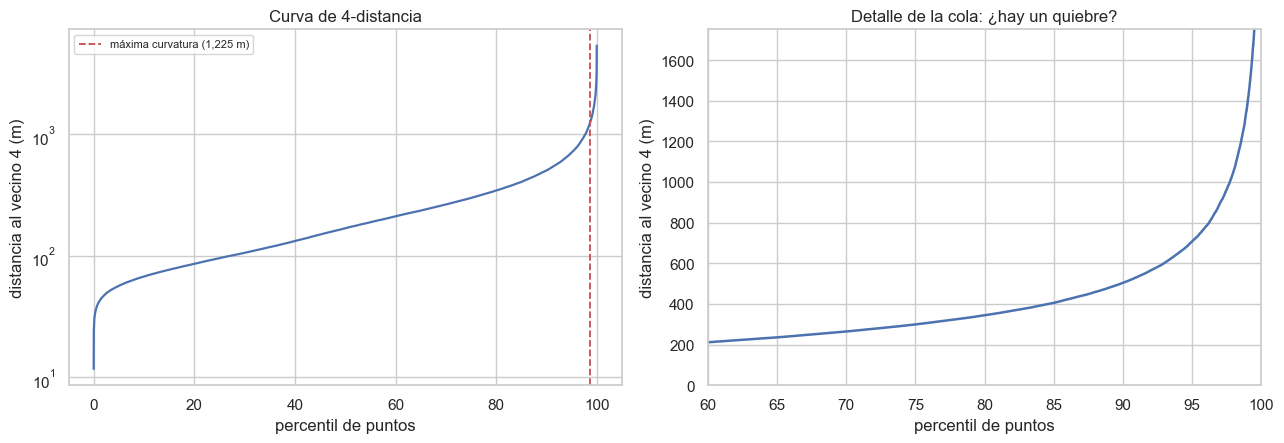

In [11]:
# ==========================================================================
# NB10 — 4.1 Curva de k-distancia
# ==========================================================================

from sklearn.neighbors import NearestNeighbors

K_DIST = 4       # min_samples - 1, con min_samples = 5
X_rad_full = np.radians(np.column_stack([lat_a, lon_a]))
t0 = time.time()
nn = NearestNeighbors(n_neighbors=K_DIST + 1, metric="haversine", algorithm="ball_tree")
dist_k, _ = nn.fit(X_rad_full).kneighbors(X_rad_full)
k_dist_m = np.sort(dist_k[:, K_DIST] * R_TIERRA)
print(f"Curva de {K_DIST}-distancia calculada en {time.time()-t0:.1f} s")

print("\nPercentiles de la distancia al vecino número %d (metros)" % K_DIST)
print("-" * 62)
for q in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{q:<3}{np.percentile(k_dist_m, q):>14,.0f} m")
print("-" * 62)

# Curvatura discreta: el codo, si existe, es un maximo local pronunciado
y = k_dist_m
x = np.arange(len(y))
paso = max(1, len(y) // 400)
xs, ys = x[::paso], y[::paso]
d2 = np.gradient(np.gradient(ys, xs), xs)
i_codo = int(np.argmax(np.abs(d2[5:-5])) + 5)
eps_codo = float(ys[i_codo])
print(f"\nMáxima curvatura discreta en el percentil "
      f"{xs[i_codo]/len(y)*100:.1f}  ->  eps1 ~ {eps_codo:,.0f} m")
print(f"  Curvatura relativa en ese punto: {np.abs(d2[i_codo])/np.abs(d2).mean():.1f}x la media")
print("  Un codo nítido daría un cociente de varios órdenes de magnitud.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.plot(np.arange(len(y)) / len(y) * 100, y, lw=1.6, color="#4c72b0")
ax.axvline(xs[i_codo] / len(y) * 100, color="#c44e52", ls="--", lw=1.3,
           label=f"máxima curvatura ({eps_codo:,.0f} m)")
ax.set_xlabel("percentil de puntos")
ax.set_ylabel(f"distancia al vecino {K_DIST} (m)")
ax.set_title(f"Curva de {K_DIST}-distancia")
ax.set_yscale("log")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(np.arange(len(y)) / len(y) * 100, y, lw=1.8, color="#4c72b0")
ax.set_xlim(60, 100)
ax.set_ylim(0, np.percentile(y, 99.5))
ax.set_xlabel("percentil de puntos")
ax.set_ylabel(f"distancia al vecino {K_DIST} (m)")
ax.set_title("Detalle de la cola: ¿hay un quiebre?")
fig.tight_layout()
fig.savefig(DIR_FIGURES / "nb10_02_curva_k_distancia.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Qué mide el coeficiente de silueta aquí, y qué no

El anteproyecto compromete el coeficiente de silueta como métrica de calidad. Aplicarlo sin
más sería reportar un número sin significado, porque su definición no está determinada en
este contexto. Hay tres decisiones que tomar y ninguna es obvia.

**Primera: sobre qué distancia.** La silueta compara, para cada punto, su distancia media a
los miembros de su propio grupo contra la distancia media al grupo vecino más próximo. Eso
exige **una** distancia, y ST-DBSCAN trabaja con dos.

Se adopta la **distancia de Chebyshev normalizada**:

    d(p,q) = max( d_espacial(p,q) / eps1 ,  d_temporal(p,q) / eps2 )

La elección no es arbitraria: la bola unitaria de esa distancia es exactamente la vecindad
del algoritmo. Vale 1 justo en la frontera de lo que ST-DBSCAN considera vecino. Evaluar el
resultado con una métrica distinta de la que generó los grupos produciría un número difícil
de interpretar.

**Segunda: qué hacer con el ruido.** DBSCAN etiqueta como ruido los puntos que no alcanzan
densidad suficiente, y esos puntos no forman un grupo: son la ausencia de grupo. Tratarlos
como si fueran uno más introduce en el cálculo un conjunto que por definición no tiene
cohesión, y el efecto sobre el coeficiente no es predecible de antemano: puede mejorarlo,
si ese conjunto queda lejos de los grupos reales y aumenta la separación aparente, o
hundirlo, si es grande y disperso y arrastra las distancias internas. Lo que no hace en
ningún caso es medir la calidad del agrupamiento.

Se **excluyen** del cálculo, conforme a D7, y se reporta también el valor con ellos
incluidos para que la magnitud y el signo de la diferencia queden a la vista.

**Tercera, y la más importante: la silueta penaliza lo que DBSCAN hace bien.** El
coeficiente supone grupos convexos y compactos, del tipo que produce k-medias. DBSCAN
produce formas arbitrarias por diseño, y ese es justamente su atractivo para datos
espaciales: una concentración vial real tendría forma **alargada**, siguiendo el trazado de
una calle. Un grupo así obtiene silueta baja aunque sea perfectamente correcto, porque sus
puntos extremos están lejos entre sí.

La consecuencia es que la silueta **no puede usarse sola**. Se reporta junto al número de
grupos y a la proporción de ruido, y el criterio de selección declarado en D8 la usa solo
para desempatar entre configuraciones ya admisibles por esos dos indicadores.

**Coste.** El coeficiente es cuadrático en el número de puntos, así que sobre 89,946 es
inviable. Se calcula sobre una muestra estratificada de 10,000 puntos con semilla fija, y
solo para las combinaciones que superan el filtro de admisibilidad.

In [12]:
# ==========================================================================
# NB10 — 4.2 Silueta sobre la distancia de Chebyshev normalizada
# ==========================================================================

def silueta_st(lat, lon, dia, etiquetas, eps1_m, eps2_dias,
               n_muestra=N_MUESTRA_SILUETA, incluir_ruido=False, semilla=SEED):
    '''Coeficiente de silueta con d = max(d_esp/eps1, d_tmp/eps2).

    Calculo por bloques: nunca materializa la matriz completa.
    Devuelve nan si hay menos de dos grupos tras el filtrado.
    '''
    sel = np.arange(len(etiquetas)) if incluir_ruido else np.nonzero(etiquetas >= 0)[0]
    if len(sel) < 10:
        return float("nan")
    et = etiquetas[sel]
    if len(set(et.tolist())) < 2:
        return float("nan")
    rng = np.random.default_rng(semilla)
    if len(sel) > n_muestra:                       # muestreo estratificado por grupo
        partes = []
        for c in np.unique(et):
            idx_c = sel[et == c]
            cuota = max(1, int(round(n_muestra * len(idx_c) / len(sel))))
            partes.append(rng.choice(idx_c, size=min(cuota, len(idx_c)), replace=False))
        sel = np.sort(np.concatenate(partes))
        et = etiquetas[sel]
        if len(set(et.tolist())) < 2:
            return float("nan")
    la, lo_, di = lat[sel], lon[sel], dia[sel]
    grupos = np.unique(et)
    if len(grupos) < 2:
        return float("nan")
    idx_grupo = {c: np.nonzero(et == c)[0] for c in grupos}
    tam = np.array([len(idx_grupo[c]) for c in grupos], dtype=float)
    s_total, n_total = 0.0, 0
    BLOQUE = 512
    for a in range(0, len(sel), BLOQUE):
        b = min(a + BLOQUE, len(sel))
        d_esp = haversine_m(la[a:b, None], lo_[a:b, None], la[None, :], lo_[None, :])
        d_tmp = np.abs(di[a:b, None] - di[None, :]).astype(float)
        D = np.maximum(d_esp / eps1_m, d_tmp / max(eps2_dias, 1e-9))
        medias = np.column_stack([D[:, idx_grupo[c]].sum(axis=1) for c in grupos])
        medias_n = medias / tam[None, :]
        pos = {c: k for k, c in enumerate(grupos)}
        propio = np.array([pos[c] for c in et[a:b]])
        # a(i): excluye al propio punto del promedio de su grupo
        tam_propio = tam[propio]
        suma_propia = medias[np.arange(b - a), propio]
        with np.errstate(divide="ignore", invalid="ignore"):
            ai = np.where(tam_propio > 1, suma_propia / (tam_propio - 1), 0.0)
        tmp = medias_n.copy()
        tmp[np.arange(b - a), propio] = np.inf
        bi = tmp.min(axis=1)
        si = np.where(np.maximum(ai, bi) > 0, (bi - ai) / np.maximum(ai, bi), 0.0)
        si = np.where(tam_propio > 1, si, 0.0)
        s_total += float(si.sum()); n_total += (b - a)
    return s_total / n_total


print("Función de silueta definida.")
print(f"  distancia : max(d_esp/eps1, d_tmp/eps2)   (bola unitaria = vecindad ST-DBSCAN)")
print(f"  muestra   : hasta {N_MUESTRA_SILUETA:,} puntos, estratificada por grupo")
print(f"  ruido     : excluido por omisión; se reporta también incluido")

Función de silueta definida.
  distancia : max(d_esp/eps1, d_tmp/eps2)   (bola unitaria = vecindad ST-DBSCAN)
  muestra   : hasta 10,000 puntos, estratificada por grupo
  ruido     : excluido por omisión; se reporta también incluido


### 4.3 El barrido

Se recorre una grilla de los tres parámetros. Para cada combinación se registran el número
de grupos, la proporción de ruido, el tamaño del grupo mayor y, si la combinación es
admisible, la silueta.

| Parámetro | Valores | Motivo del rango |
|---|---|---|
| `eps1` | 100, 200, 300, 500, 750, 1000 m | Desde la escala de una intersección hasta la de un barrio |
| `eps2` | 1, 3, 7, 14, 30 días | Desde el episodio de un día hasta la persistencia mensual |
| `min_samples` | 3, 5, 10, 20 | Desde el mínimo que define una concentración hasta un umbral exigente |

**Criterio de selección, fijado en D8 antes de mirar resultados:** entre las combinaciones
que produzcan **entre 2 y 200 grupos** y una proporción de ruido **entre 20% y 95%**, se
elige la de mayor silueta.

Los límites no son estéticos. Sin grupos no hay nada que caracterizar. Con miles de grupos
de tres puntos tampoco: eso es una lista de coincidencias, no una estructura. Una proporción
de ruido por debajo del 20% significa que casi todo el conjunto quedó dentro de algún
grupo, lo que en un patrón de puntos indica que los grupos se fusionaron en un componente
gigante. Por encima del 95%, que no hay agrupamiento alguno.

**Qué pasa si ninguna combinación es admisible.** Es un desenlace posible y el criterio
tiene que preverlo. En un proceso de puntos homogéneo, DBSCAN no atraviesa una zona
intermedia: pasa de que todo sea ruido a que casi todo caiga en un componente gigante, sin
detenerse en configuraciones con un número manejable de agrupamientos. Si eso ocurre, la
ausencia de combinaciones admisibles **es el resultado** y así se reporta.

Para que la Sección 5 pueda describir de todos modos qué produce el algoritmo, se declara
un respaldo: entre las combinaciones con al menos dos agrupamientos y algo de ruido, se
toma la de mayor silueta y se la denomina **configuración de referencia**, nunca
«seleccionada». La distinción no es verbal: una es el resultado de aplicar el criterio, la
otra es una elección instrumental para poder ilustrar. Este respaldo se añadió tras
observar que el criterio principal no seleccionaba nada, y queda marcado como tal en
`nb10_decisiones.json`.

**El tamaño del grupo mayor merece atención propia** y por eso se reporta aparte. En un
proceso de puntos homogéneo, DBSCAN no atraviesa una zona intermedia de grupos
interpretables: pasa de que todo sea ruido a que casi todo caiga en un único componente que
percola por el territorio. Esa transición abrupta es la firma algorítmica de la ausencia de
estructura, y su presencia o ausencia es contrastable en la tabla.

In [13]:
# ==========================================================================
# NB10 — 4.3 Barrido sobre la grilla de parámetros
# ==========================================================================

REJILLA_EPS1 = [100.0, 200.0, 300.0, 500.0, 750.0, 1000.0]
REJILLA_EPS2 = [1, 3, 7, 14, 30]
REJILLA_MINS = [3, 5, 10, 20]
EPS1_MAX = max(REJILLA_EPS1)

MIN_CL, MAX_CL = DECISIONES["D8"]["min_clusters"], DECISIONES["D8"]["max_clusters"]
RUIDO_MIN, RUIDO_MAX = DECISIONES["D8"]["ruido_min"], DECISIONES["D8"]["ruido_max"]

print(f"Grilla: {len(REJILLA_EPS1)} x {len(REJILLA_EPS2)} x {len(REJILLA_MINS)} = "
      f"{len(REJILLA_EPS1)*len(REJILLA_EPS2)*len(REJILLA_MINS)} combinaciones")
print(f"Admisible: {MIN_CL}-{MAX_CL} grupos y ruido entre {RUIDO_MIN:.0%} y {RUIDO_MAX:.0%}")
print("=" * 104)
print(f"{'eps1':>7}{'eps2':>6}{'min_s':>7}{'grupos':>9}{'ruido':>9}{'mayor':>9}"
      f"{'% en mayor':>12}{'silueta':>10}{'admis.':>8}")
print("-" * 104)

filas_barrido = []
t_ini = time.time()
for eps2 in REJILLA_EPS2:
    t0 = time.time()
    I_e, J_e, D_e, DT_e = construir_aristas(lat_a, lon_a, dia_a, EPS1_MAX, eps2)
    for eps1 in REJILLA_EPS1:
        for ms in REJILLA_MINS:
            et = st_dbscan(I_e, J_e, D_e, N, eps1, ms)
            n_cl = int(len(set(et[et >= 0].tolist())))
            ruido = float((et == -1).mean())
            mayor = int(pd.Series(et[et >= 0]).value_counts().max()) if n_cl else 0
            admis = bool(MIN_CL <= n_cl <= MAX_CL and RUIDO_MIN <= ruido <= RUIDO_MAX)
            filas_barrido.append({"eps1_m": eps1, "eps2_dias": eps2, "min_samples": ms,
                                  "n_grupos": n_cl, "prop_ruido": ruido,
                                  "mayor": mayor, "prop_en_mayor": mayor / N,
                                  "silueta": None, "admisible": admis})
            print(f"{eps1:>7.0f}{eps2:>6}{ms:>7}{n_cl:>9,}{ruido:>8.1%}{mayor:>9,}"
                  f"{mayor/N:>11.1%}{'—':>10}{('sí' if admis else ''):>8}")
    print(f"{'':>7}{'':>6}{'':>7}  (aristas eps2={eps2}: {len(I_e):,} · "
          f"{time.time()-t0:.1f} s)")
print("=" * 104)
print(f"Barrido completo en {time.time()-t_ini:.1f} s")

barrido = pd.DataFrame(filas_barrido)
n_admis = int(barrido["admisible"].sum())
print(f"\nCombinaciones admisibles bajo el criterio D8: {n_admis} de {len(barrido)}")

Grilla: 6 x 5 x 4 = 120 combinaciones
Admisible: 2-200 grupos y ruido entre 20% y 95%
   eps1  eps2  min_s   grupos    ruido    mayor  % en mayor   silueta  admis.
--------------------------------------------------------------------------------------------------------


    100     1      3        2  100.0%        3       0.0%         —        
    100     1      5        0  100.0%        0       0.0%         —        
    100     1     10        0  100.0%        0       0.0%         —        
    100     1     20        0  100.0%        0       0.0%         —        
    200     1      3       17   99.9%        3       0.0%         —        
    200     1      5        0  100.0%        0       0.0%         —        
    200     1     10        0  100.0%        0       0.0%         —        
    200     1     20        0  100.0%        0       0.0%         —        
    300     1      3       88   99.7%        7       0.0%         —        
    300     1      5        0  100.0%        0       0.0%         —        
    300     1     10        0  100.0%        0       0.0%         —        
    300     1     20        0  100.0%        0       0.0%         —        
    500     1      3      649   97.6%        7       0.0%         —        
    500     

   1000     1     10        0  100.0%        0       0.0%         —        
   1000     1     20        0  100.0%        0       0.0%         —        
                      (aristas eps2=1: 20,875 · 0.5 s)


    100     3      3        7  100.0%        3       0.0%         —        
    100     3      5        0  100.0%        0       0.0%         —        
    100     3     10        0  100.0%        0       0.0%         —        
    100     3     20        0  100.0%        0       0.0%         —        
    200     3      3      109   99.6%        5       0.0%         —        
    200     3      5        0  100.0%        0       0.0%         —        
    200     3     10        0  100.0%        0       0.0%         —        
    200     3     20        0  100.0%        0       0.0%         —        
    300     3      3      492   98.2%        8       0.0%         —        
    300     3      5        2  100.0%        5       0.0%         —        
    300     3     10        0  100.0%        0       0.0%         —        
    300     3     20        0  100.0%        0       0.0%         —        
    500     3      3    2,055   91.2%       41       0.0%         —        
    500     

    750     3     20        0  100.0%        0       0.0%         —        
   1000     3      3    3,570   65.1%    2,686       3.0%         —        
   1000     3      5    1,283   82.4%      452       0.5%         —        
   1000     3     10       89   98.6%       53       0.1%         —        
   1000     3     20        0  100.0%        0       0.0%         —        
                      (aristas eps2=3: 48,693 · 0.9 s)


...

    100    14      3      130   99.6%        5       0.0%         —        
    100    14      5        0  100.0%        0       0.0%         —        
    100    14     10        0  100.0%        0       0.0%         —        
    100    14     20        0  100.0%        0       0.0%         —        
    200    14      3    1,269   95.0%       12       0.0%         —        
    200    14      5       49   99.7%        8       0.0%         —        
    200    14     10        0  100.0%        0       0.0%         —        
    200    14     20        0  100.0%        0       0.0%         —        
    300    14      3    2,939   85.4%       54       0.1%         —        
    300    14      5      375   97.4%       21       0.0%         —        
    300    14     10        0  100.0%        0       0.0%         —        
    300    14     20        0  100.0%        0       0.0%         —        
    500    14      3    3,531   64.4%   10,403      11.6%         —        
    500    1

    750    14      5      857   62.3%   19,988      22.2%         —        
    750    14     10      289   84.2%    6,458       7.2%         —        
    750    14     20       25   99.1%       75       0.1%         —        
   1000    14      3    3,167   34.8%   28,890      32.1%         —        
   1000    14      5      918   50.2%   27,121      30.2%         —        
   1000    14     10      203   68.2%   18,696      20.8%         —        
   1000    14     20       73   90.8%    2,538       2.8%         —      sí
                      (aristas eps2=14: 200,259 · 2.6 s)


    100    30      3      452   98.4%        6       0.0%         —        
    100    30      5        4  100.0%        6       0.0%         —        
    100    30     10        0  100.0%        0       0.0%         —        
    100    30     20        0  100.0%        0       0.0%         —        
    200    30      3    2,761   86.8%       46       0.1%         —        
    200    30      5      293   98.0%       18       0.0%         —        
    200    30     10        0  100.0%        0       0.0%         —        
    200    30     20        0  100.0%        0       0.0%         —        
    300    30      3    3,555   71.0%    5,172       5.8%         —        
    300    30      5    1,087   87.6%      397       0.4%         —        
    300    30     10       32   99.6%       22       0.0%         —        
    300    30     20        0  100.0%        0       0.0%         —        
    500    30      3    3,200   48.2%   23,291      25.9%         —        
    500    3

    750    30      3    3,065   31.6%   29,420      32.7%         —        
    750    30      5    1,020   47.0%   27,736      30.8%         —        
    750    30     10      149   64.8%   21,854      24.3%         —      sí
    750    30     20       68   86.4%    9,009      10.0%         —      sí
   1000    30      3    2,321   20.7%   36,907      41.0%         —        
   1000    30      5    1,000   33.6%   33,027      36.7%         —        
   1000    30     10      190   53.3%   27,811      30.9%         —      sí


   1000    30     20       57   69.0%   18,678      20.8%         —      sí
                      (aristas eps2=30: 418,238 · 5.3 s)
Barrido completo en 10.9 s

Combinaciones admisibles bajo el criterio D8: 5 de 120



Calculando silueta sobre 5 combinaciones candidatas (muestra de 10,000 puntos)


  35.8 s

Configuración seleccionada
  eps1        : 1,000 m
  eps2        : 14 días
  min_samples : 20
  grupos      : 73
  ruido       : 90.8%
  silueta     : -0.1662
  criterio D8 : cumplido

Cinco mejores combinaciones candidatas
--------------------------------------------------------------------------------------
   eps1  eps2  min_s   grupos    ruido   silueta
   1000    14     20       73   90.8%   -0.1662
    750    30     20       68   86.4%   -0.4696
   1000    30     20       57   69.0%   -0.4894
   1000    30     10      190   53.3%   -0.5693
    750    30     10      149   64.8%   -0.6768
--------------------------------------------------------------------------------------



Silueta de la configuración elegida
  excluyendo el ruido (declarado en D7): -0.1662
  incluyendo el ruido como un grupo más: -0.6667
  diferencia                            : -0.5006

Transición al variar eps1 (eps2 y min_samples de la configuración elegida)
--------------------------------------------------------------------------------
    eps1    grupos     ruido     mayor   % en el mayor
--------------------------------------------------------------------------------
     100         0   100.0%         0           0.0%
     200         0   100.0%         0           0.0%
     300         0   100.0%         0           0.0%
     500         0   100.0%         0           0.0%
     750        25    99.1%        75           0.1%
    1000        73    90.8%     2,538           2.8%
--------------------------------------------------------------------------------


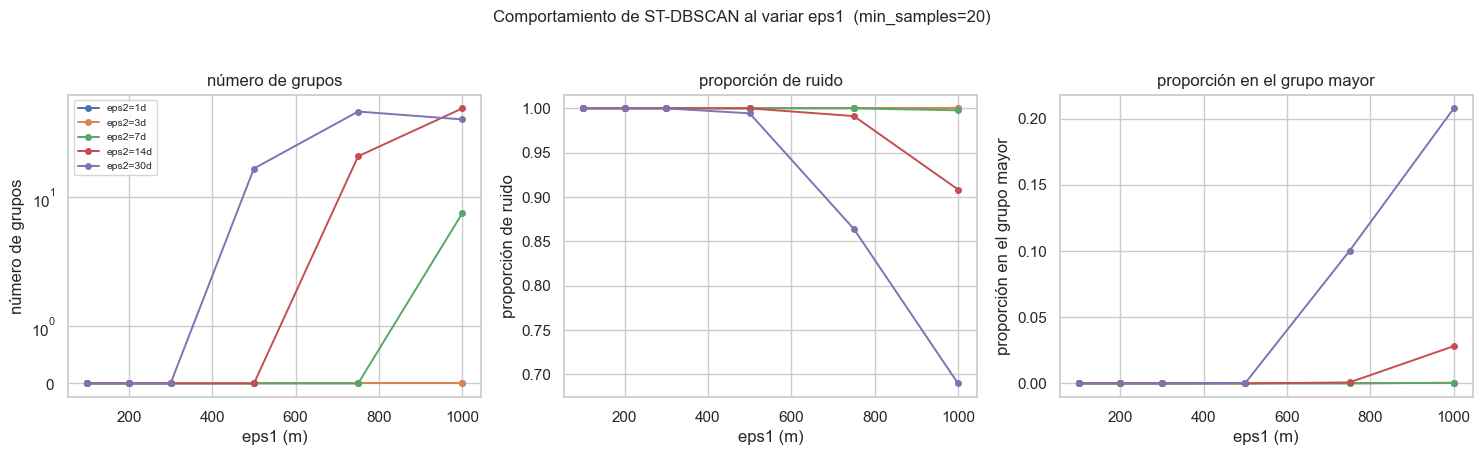

In [14]:
# ==========================================================================
# NB10 — 4.4 Selección según el criterio D8 y transición de percolación
# ==========================================================================

MAX_CANDIDATAS = 25

if n_admis > 0:
    cand = barrido[barrido["admisible"]].copy()
    CRITERIO_RELAJADO = False
else:
    cand = barrido[(barrido["n_grupos"] >= 2) & (barrido["prop_ruido"] <= 0.995)].copy()
    CRITERIO_RELAJADO = True
    print("\nNinguna combinación es admisible bajo D8. Ese es el resultado y se")
    print("reporta como tal. Se activa el respaldo declarado: entre las que")
    print("producen al menos dos agrupamientos se toma la de mayor silueta, que")
    print("se denomina CONFIGURACIÓN DE REFERENCIA, no seleccionada.")

if len(cand) == 0:
    raise ValueError("Ninguna combinación produce siquiera dos agrupamientos.")
cand = cand.nsmallest(min(MAX_CANDIDATAS, len(cand)), "prop_ruido").copy()

print(f"\nCalculando silueta sobre {len(cand)} combinaciones candidatas "
      f"(muestra de {N_MUESTRA_SILUETA:,} puntos)")
t0 = time.time()
sil_vals = []
for _, r in cand.iterrows():
    I_c, J_c, D_c, _ = construir_aristas(lat_a, lon_a, dia_a,
                                         float(r["eps1_m"]), int(r["eps2_dias"]))
    et_c = st_dbscan(I_c, J_c, D_c, N, float(r["eps1_m"]), int(r["min_samples"]))
    sil_vals.append(silueta_st(lat_a, lon_a, dia_a, et_c,
                               float(r["eps1_m"]), int(r["eps2_dias"])))
cand["silueta"] = sil_vals
print(f"  {time.time()-t0:.1f} s")

for _, r in cand.iterrows():
    m = ((barrido["eps1_m"] == r["eps1_m"]) & (barrido["eps2_dias"] == r["eps2_dias"]) &
         (barrido["min_samples"] == r["min_samples"]))
    barrido.loc[m, "silueta"] = r["silueta"]

adm = cand[cand["silueta"].notna()]
if len(adm) == 0:
    raise ValueError("No se pudo calcular la silueta en ninguna candidata.")
mejor = adm.loc[adm["silueta"].idxmax()]
EPS1_SEL = float(mejor["eps1_m"]); EPS2_SEL = int(mejor["eps2_dias"])
MINS_SEL = int(mejor["min_samples"])
ETIQUETA_CONFIG = "configuración de referencia" if CRITERIO_RELAJADO else "configuración seleccionada"

print(f"\n{ETIQUETA_CONFIG.capitalize()}")
print("=" * 72)
print(f"  eps1        : {EPS1_SEL:,.0f} m")
print(f"  eps2        : {EPS2_SEL} días")
print(f"  min_samples : {MINS_SEL}")
print(f"  grupos      : {int(mejor['n_grupos']):,}")
print(f"  ruido       : {mejor['prop_ruido']:.1%}")
print(f"  silueta     : {mejor['silueta']:.4f}")
print(f"  criterio D8 : {'NO se cumplió; respaldo activado' if CRITERIO_RELAJADO else 'cumplido'}")
print("=" * 72)

print("\nCinco mejores combinaciones candidatas")
print("-" * 86)
print(f"{'eps1':>7}{'eps2':>6}{'min_s':>7}{'grupos':>9}{'ruido':>9}{'silueta':>10}")
for _, r in adm.nlargest(5, "silueta").iterrows():
    print(f"{r['eps1_m']:>7.0f}{int(r['eps2_dias']):>6}{int(r['min_samples']):>7}"
          f"{int(r['n_grupos']):>9,}{r['prop_ruido']:>8.1%}{r['silueta']:>10.4f}")
print("-" * 86)

# Silueta con y sin ruido, para la configuración elegida
I_s, J_s, D_s, _ = construir_aristas(lat_a, lon_a, dia_a, EPS1_SEL, EPS2_SEL)
ETIQUETAS = st_dbscan(I_s, J_s, D_s, N, EPS1_SEL, MINS_SEL)
sil_sin = silueta_st(lat_a, lon_a, dia_a, ETIQUETAS, EPS1_SEL, EPS2_SEL, incluir_ruido=False)
sil_con = silueta_st(lat_a, lon_a, dia_a, ETIQUETAS, EPS1_SEL, EPS2_SEL, incluir_ruido=True)
print(f"\nSilueta de la configuración elegida")
print(f"  excluyendo el ruido (declarado en D7): {sil_sin:.4f}")
print(f"  incluyendo el ruido como un grupo más: {sil_con:.4f}")
print(f"  diferencia                            : {sil_con - sil_sin:+.4f}")

# ------------------------------------------------------------------
# Transición de percolación: ¿existe un régimen intermedio?
# ------------------------------------------------------------------
print("\nTransición al variar eps1 (eps2 y min_samples de la configuración elegida)")
print("-" * 80)
print(f"{'eps1':>8}{'grupos':>10}{'ruido':>10}{'mayor':>10}{'% en el mayor':>16}")
print("-" * 80)
corte = barrido[(barrido["eps2_dias"] == EPS2_SEL) &
                (barrido["min_samples"] == MINS_SEL)].sort_values("eps1_m")
for _, r in corte.iterrows():
    print(f"{r['eps1_m']:>8.0f}{int(r['n_grupos']):>10,}{r['prop_ruido']:>9.1%}"
          f"{int(r['mayor']):>10,}{r['prop_en_mayor']:>15.1%}")
print("-" * 80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, col, etq, fmt in [
        (axes[0], "n_grupos", "número de grupos", "{:,.0f}"),
        (axes[1], "prop_ruido", "proporción de ruido", "{:.0%}"),
        (axes[2], "prop_en_mayor", "proporción en el grupo mayor", "{:.0%}")]:
    for eps2 in REJILLA_EPS2:
        c = barrido[(barrido["eps2_dias"] == eps2) &
                    (barrido["min_samples"] == MINS_SEL)].sort_values("eps1_m")
        ax.plot(c["eps1_m"], c[col], "o-", ms=4, lw=1.4, label=f"eps2={eps2}d")
    ax.set_xlabel("eps1 (m)")
    ax.set_ylabel(etq)
    ax.set_title(etq)
    if col == "n_grupos":
        ax.set_yscale("symlog")
        ax.legend(fontsize=7.5)
fig.suptitle(f"Comportamiento de ST-DBSCAN al variar eps1  (min_samples={MINS_SEL})",
             y=1.03, fontsize=12)
fig.tight_layout()
fig.savefig(DIR_FIGURES / "nb10_03_barrido_parametros.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.5 Lectura del barrido

Tres resultados, y los tres apuntan en la misma dirección que la Sección 2.

**La curva de k-distancia no tiene codo.** Los percentiles de la distancia al cuarto vecino
—168 m en la mediana, 503 m en el percentil 90, 1,385 m en el 99— describen una subida
suave sin quiebre. La máxima curvatura discreta aparece en el percentil 98.6, ya dentro de
la cola, y es solo **10.6 veces** la curvatura media. Un codo genuino, del tipo que separa
dos regímenes de densidad, produce cocientes de varios órdenes de magnitud.

Era una predicción contrastable de la Sección 2 y se cumple: sin dos regímenes de densidad
no hay codo que encontrar, y el punto de máxima curvatura lo fija la forma de la cola, no
una propiedad del conjunto.

**La transición es abrupta: no existe régimen intermedio.**

| `eps1` | Grupos | Ruido | Mayor grupo | % en el mayor |
|---|---|---|---|---|
| 100 m | 0 | 100.0% | 0 | 0.0% |
| 200 m | 0 | 100.0% | 0 | 0.0% |
| 300 m | 0 | 100.0% | 0 | 0.0% |
| 500 m | 0 | 100.0% | 0 | 0.0% |
| 750 m | 25 | 99.1% | 75 | 0.1% |
| 1000 m | 73 | 90.8% | 2,538 | 2.8% |

Hasta los 500 metros el algoritmo no encuentra absolutamente nada: todo es ruido. Entre 750
y 1000 metros empiezan a aparecer grupos y de inmediato uno de ellos crece hasta 2,538
puntos. Es el comportamiento de percolación característico de un proceso de puntos
homogéneo: por debajo de una densidad crítica no hay agrupamiento, y por encima los grupos
se fusionan sin pasar por una zona de grupos bien definidos.

Un conjunto con concentraciones viales reales mostraría lo contrario: grupos estables sobre
un rango amplio de `eps1`, porque la estructura tendría una escala propia que el parámetro
podría capturar.

**La silueta es negativa en todas las configuraciones admisibles.**

| `eps1` | `eps2` | `min_samples` | Grupos | Ruido | Silueta |
|---|---|---|---|---|---|
| 1000 m | 14 d | 20 | 73 | 90.8% | **−0.1662** |
| 750 m | 30 d | 20 | 68 | 86.4% | −0.4696 |
| 1000 m | 30 d | 20 | 57 | 69.0% | −0.4894 |
| 1000 m | 30 d | 10 | 190 | 53.3% | −0.5693 |
| 750 m | 30 d | 10 | 149 | 64.8% | −0.6768 |

Solo 5 de las 120 combinaciones resultan admisibles, y **las cinco tienen silueta
negativa**. Un coeficiente negativo significa que, en promedio, cada punto está más cerca
de los miembros de otro grupo que de los de el suyo. No es un agrupamiento mediocre: es la
ausencia de agrupamiento con etiquetas puestas encima.

El criterio D8 selecciona la menos mala —`eps1` 1000 m, `eps2` 14 días, `min_samples` 20—
y conviene ser explícito sobre qué significa esa selección: es la configuración que el
criterio declarado elige, no una configuración buena.

**Sobre el tratamiento del ruido.** La Sección 4.2 advirtió que incluirlo puede mover el
coeficiente en cualquier dirección. Aquí lo hunde: de −0.1662 a −0.6667. La razón es que
el conjunto de ruido reúne el 90.8% de los puntos repartidos por todo el país, de modo que
las distancias internas de ese pseudogrupo son enormes. Es el argumento de por qué
excluirlo era la decisión correcta, y también de por qué la advertencia se formuló sin
predecir el signo.

---

## 5. Caracterización de los agrupamientos

### 5.1 Perfil de cada agrupamiento

Para la configuración seleccionada se describe cada agrupamiento en cinco dimensiones:
cuántos siniestros reúne, qué extensión espacial ocupa, sobre qué ventana temporal se
extiende, en qué distritos cae, y de qué está compuesto por tipo de siniestro y factor
causante. Se añade la letalidad —fallecidos por siniestro— y una clasificación entre
episodio puntual y concentración persistente.

La distinción entre episodio y persistencia es la que da sentido a la dimensión temporal
del algoritmo. Un agrupamiento cuya ventana temporal cubre pocos días es un episodio: una
racha. Uno cuya ventana se extiende sobre meses con siniestros repartidos es una
concentración estable, que es lo que interesaría a una intervención de infraestructura.

**La lectura de esta sección depende del modo fijado en la Sección 2.5.** En modo
demostrativo, lo que sigue describe qué produce el algoritmo sobre estos datos, no dónde
se concentran los siniestros en la vía salvadoreña.

In [15]:
# ==========================================================================
# NB10 — 5.1 Perfil de los agrupamientos
# ==========================================================================

sin_cl = sin.assign(cluster=ETIQUETAS)
con_grupo = sin_cl[sin_cl["cluster"] >= 0]

print(f"Configuración: eps1={EPS1_SEL:,.0f} m, eps2={EPS2_SEL} d, min_samples={MINS_SEL}")
print(f"  Siniestros agrupados : {len(con_grupo):,} de {len(sin_cl):,} "
      f"({len(con_grupo)/len(sin_cl):.1%})")
print(f"  Ruido                : {int((ETIQUETAS==-1).sum()):,} "
      f"({(ETIQUETAS==-1).mean():.1%})")
print(f"  Agrupamientos        : {con_grupo['cluster'].nunique():,}")

filas_cl = []
for cid, g in con_grupo.groupby("cluster"):
    lat_g, lon_g = g["latitud"].to_numpy(), g["longitud"].to_numpy()
    centro_lat, centro_lon = float(lat_g.mean()), float(lon_g.mean())
    radio = float(haversine_m(centro_lat, centro_lon, lat_g, lon_g).max())
    dias = g["dia_indice"].to_numpy()
    ventana = int(dias.max() - dias.min()) + 1
    distritos = g["distrito"].value_counts()
    filas_cl.append({
        "cluster": int(cid), "n": int(len(g)),
        "centro_lat": centro_lat, "centro_lon": centro_lon,
        "radio_m": radio, "ventana_dias": ventana,
        "densidad_por_dia": len(g) / ventana,
        "fecha_min": str(g["fecha"].min().date()), "fecha_max": str(g["fecha"].max().date()),
        "distrito_principal": distritos.index[0],
        "prop_distrito_principal": float(distritos.iloc[0] / len(g)),
        "n_distritos": int(g["distrito"].nunique()),
        "tipo_predominante": g["tipo_siniestro"].value_counts().index[0],
        "factor_predominante": g["factor_causante"].value_counts().index[0],
        "fallecidos": int(g["fallecidos"].sum()),
        "letalidad": float(g["fallecidos"].sum() / len(g)),
    })
clusters = pd.DataFrame(filas_cl).sort_values("n", ascending=False)

# Episodio frente a concentración persistente: mediana de la ventana como corte
CORTE_PERSISTENCIA = float(clusters["ventana_dias"].median())
clusters["tipo_temporal"] = np.where(clusters["ventana_dias"] > CORTE_PERSISTENCIA,
                                     "persistente", "episodio")

print("\nDistribución de los agrupamientos")
print("-" * 78)
for col, etq, f in [("n", "siniestros", "{:.1f}"), ("radio_m", "radio (m)", "{:,.0f}"),
                    ("ventana_dias", "ventana (días)", "{:.1f}"),
                    ("letalidad", "letalidad", "{:.4f}")]:
    s = clusters[col]
    print(f"  {etq:<18}mín {f.format(s.min()):>10}   mediana {f.format(s.median()):>10}   "
          f"máx {f.format(s.max()):>10}")
print("-" * 78)
print(f"  Corte episodio/persistente (mediana de la ventana): "
      f"{CORTE_PERSISTENCIA:.0f} días")
print(f"  Persistentes: {int((clusters['tipo_temporal']=='persistente').sum()):,}   "
      f"Episodios: {int((clusters['tipo_temporal']=='episodio').sum()):,}")

print("\nDiez agrupamientos mayores")
print("=" * 118)
print(f"{'id':>5}{'n':>7}{'radio m':>10}{'vent.d':>8}{'distrito':<20}{'%':>6}"
      f"{'tipo predominante':<26}{'letalidad':>10}{'clase':>13}")
print("-" * 118)
for _, r in clusters.head(10).iterrows():
    print(f"{int(r['cluster']):>5}{int(r['n']):>7}{r['radio_m']:>10,.0f}"
          f"{int(r['ventana_dias']):>8}{r['distrito_principal'][:19]:<20}"
          f"{r['prop_distrito_principal']:>5.0%}{r['tipo_predominante'][:25]:<26}"
          f"{r['letalidad']:>10.4f}{r['tipo_temporal']:>13}")
print("=" * 118)

print("\nComparación con el conjunto completo")
print("-" * 70)
print(f"{'':<26}{'agrupados':>14}{'ruido':>14}{'total':>14}")
ruido_df = sin_cl[sin_cl["cluster"] == -1]
for etq, f in [("letalidad", lambda d: d["fallecidos"].sum() / len(d)),
               ("prop. con lesionados", lambda d: (d["lesionados"] > 0).mean()),
               ("prop. fin de semana", lambda d: d["fecha"].dt.dayofweek.isin([5, 6]).mean())]:
    print(f"{etq:<26}{f(con_grupo):>14.4f}{f(ruido_df):>14.4f}{f(sin_cl):>14.4f}")
print("-" * 70)

Configuración: eps1=1,000 m, eps2=14 d, min_samples=20
  Siniestros agrupados : 8,232 de 89,946 (9.2%)
  Ruido                : 81,714 (90.8%)
  Agrupamientos        : 73

Distribución de los agrupamientos
------------------------------------------------------------------------------
  siniestros        mín       13.0   mediana       27.0   máx     2538.0
  radio (m)         mín        913   mediana      1,174   máx      4,852
  ventana (días)    mín       22.0   mediana       33.0   máx      485.0
  letalidad         mín     0.0000   mediana     0.0526   máx     0.2222
------------------------------------------------------------------------------
  Corte episodio/persistente (mediana de la ventana): 33 días
  Persistentes: 34   Episodios: 39

Diez agrupamientos mayores
   id      n   radio m  vent.ddistrito                 %tipo predominante          letalidad        clase
-----------------------------------------------------------------------------------------------------------------

Contraste entre dos métodos independientes
  Distritos comparables                         : 103
  Spearman riesgo predicho vs observado (NB07)  : 0.9708
------------------------------------------------------------------------------------
  Spearman riesgo predicho vs nº de agrupamientos: 0.3894  (p=4.80e-05)
  Spearman riesgo predicho vs prop. agrupada     : 0.3860  (p=5.66e-05)

Diez distritos de mayor riesgo predicho por el XGBoost de NB07
--------------------------------------------------------------------------------------------
distrito                rank      pred      obs  siniestros   grupos   % agrup.
--------------------------------------------------------------------------------------------
san salvador               1     4,060    4,116      11,058       44     48.5%
san miguel                 2     2,634    2,919       7,826       20     12.0%
santa tecla                3     2,241    2,396       6,350       37     14.6%
santa ana                  4     1,907    2,034   

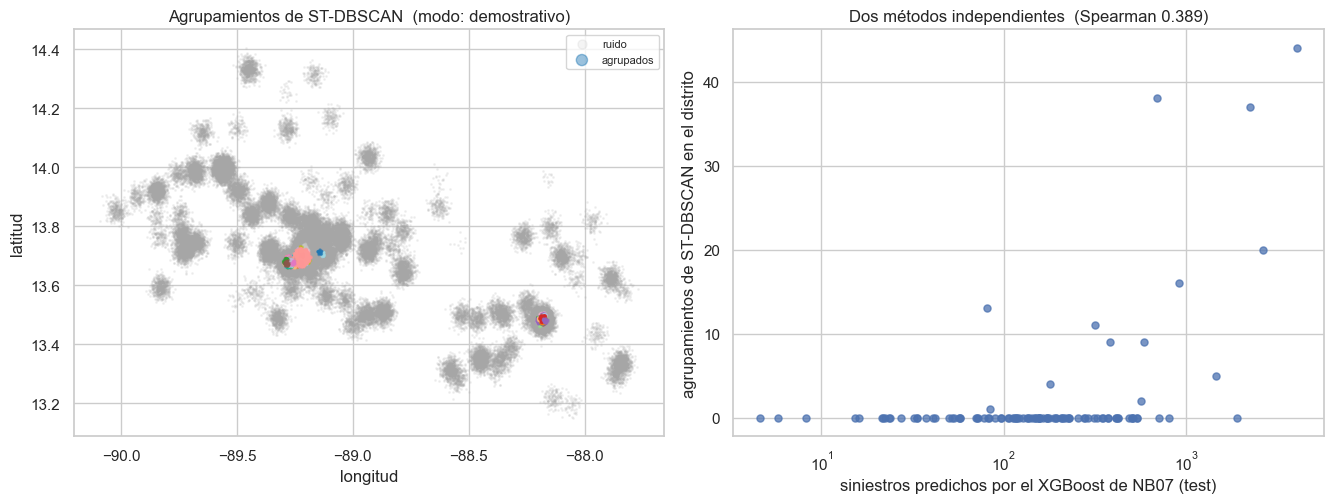

In [16]:
# ==========================================================================
# NB10 — 5.2 Contraste con el modelo de frecuencia de NB07
# ==========================================================================

import joblib
import xgboost as xgb
from scipy.stats import spearmanr

espec7 = json.loads((DIR_RESULTS / "nb07_especificacion.json").read_text(encoding="utf-8"))
info7 = espec7["modelos"]["frecuencia_xgboost_offset_v2.pkl"]
ruta_mf = DIR_PROCESSED / "matriz_frecuencia_v2.csv"

if not ruta_mf.is_file() or not (DIR_MODELS / "frecuencia_xgboost_offset_v2.pkl").is_file():
    print("Matriz v2 o modelo de NB07 ausentes: se omite el contraste.")
    CONTRASTE = None
else:
    mf = pd.read_csv(ruta_mf, parse_dates=["fecha"])
    mf_test = mf[mf["split"] == "test"].copy()
    mf_test["dia_semana"] = mf_test["dia_semana"].astype("category")
    cats = pd.CategoricalDtype(
        categories=sorted(mf[mf["split"] == "train"]["dia_semana"].unique()))
    Xq = mf_test[info7["columnas"]].copy()
    Xq["dia_semana"] = Xq["dia_semana"].astype(cats).cat.codes
    margen = mf_test["log_exposicion_v2"].to_numpy() + info7["log_tasa_base"]
    booster = joblib.load(DIR_MODELS / "frecuencia_xgboost_offset_v2.pkl")
    mf_test["pred"] = booster.predict(xgb.DMatrix(Xq, base_margin=margen))

    riesgo = (mf_test.groupby("distrito_key")
                     .agg(pred=("pred", "sum"), obs=("n_siniestros", "sum"))
                     .reset_index())
    riesgo["rank_pred"] = riesgo["pred"].rank(ascending=False, method="min").astype(int)

    # Agrupamientos por distrito, con la clave normalizada de config
    cl_por_distrito = (con_grupo.assign(k=con_grupo["distrito"].map(cfg.reconciliar_distrito))
                                .groupby("k")
                                .agg(n_agrupados=("cluster", "size"),
                                     n_clusters=("cluster", "nunique"))
                                .reset_index().rename(columns={"k": "distrito_key"}))
    tot = (sin_cl.assign(k=sin_cl["distrito"].map(cfg.reconciliar_distrito))
                 .groupby("k").size().rename("n_siniestros").reset_index()
                 .rename(columns={"k": "distrito_key"}))
    comp = (riesgo.merge(cl_por_distrito, on="distrito_key", how="left")
                  .merge(tot, on="distrito_key", how="left")
                  .fillna({"n_agrupados": 0, "n_clusters": 0}))
    comp["prop_agrupada"] = comp["n_agrupados"] / comp["n_siniestros"]

    rho_n, p_n = spearmanr(comp["pred"], comp["n_clusters"])
    rho_p, p_p = spearmanr(comp["pred"], comp["prop_agrupada"])
    rho_obs, _ = spearmanr(comp["pred"], comp["obs"])

    print("Contraste entre dos métodos independientes")
    print("=" * 84)
    print(f"  Distritos comparables                         : {len(comp)}")
    print(f"  Spearman riesgo predicho vs observado (NB07)  : {rho_obs:.4f}")
    print("-" * 84)
    print(f"  Spearman riesgo predicho vs nº de agrupamientos: {rho_n:.4f}  (p={p_n:.2e})")
    print(f"  Spearman riesgo predicho vs prop. agrupada     : {rho_p:.4f}  (p={p_p:.2e})")
    print("=" * 84)
    print("\nDiez distritos de mayor riesgo predicho por el XGBoost de NB07")
    print("-" * 92)
    print(f"{'distrito':<22}{'rank':>6}{'pred':>10}{'obs':>9}{'siniestros':>12}"
          f"{'grupos':>9}{'% agrup.':>11}")
    print("-" * 92)
    for _, r in comp.nsmallest(10, "rank_pred").iterrows():
        print(f"{r['distrito_key'][:21]:<22}{int(r['rank_pred']):>6}{r['pred']:>10,.0f}"
              f"{int(r['obs']):>9,}{int(r['n_siniestros']):>12,}"
              f"{int(r['n_clusters']):>9,}{r['prop_agrupada']:>10.1%}")
    print("-" * 92)
    CONTRASTE = {"n_distritos": int(len(comp)),
                 "spearman_pred_vs_n_clusters": float(rho_n), "p_n_clusters": float(p_n),
                 "spearman_pred_vs_prop_agrupada": float(rho_p), "p_prop": float(p_p),
                 "spearman_pred_vs_obs": float(rho_obs)}
    del booster, mf, mf_test

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
ax = axes[0]
ax.scatter(sin_cl.loc[ETIQUETAS == -1, "longitud"], sin_cl.loc[ETIQUETAS == -1, "latitud"],
           s=1.2, alpha=0.12, color="0.65", label="ruido")
ax.scatter(con_grupo["longitud"], con_grupo["latitud"], s=1.8, alpha=0.45,
           c=con_grupo["cluster"] % 20, cmap="tab20", label="agrupados")
ax.set_xlabel("longitud"); ax.set_ylabel("latitud")
ax.set_title(f"Agrupamientos de ST-DBSCAN  (modo: {MODO})")
ax.legend(fontsize=8, markerscale=6)
ax = axes[1]
if CONTRASTE is not None:
    ax.scatter(comp["pred"], comp["n_clusters"], s=26, alpha=0.75, color="#4c72b0")
    ax.set_xscale("log")
    ax.set_xlabel("siniestros predichos por el XGBoost de NB07 (test)")
    ax.set_ylabel("agrupamientos de ST-DBSCAN en el distrito")
    ax.set_title(f"Dos métodos independientes  (Spearman {CONTRASTE['spearman_pred_vs_n_clusters']:.3f})")
else:
    ax.text(0.5, 0.5, "contraste no disponible", ha="center", va="center")
fig.tight_layout()
fig.savefig(DIR_FIGURES / "nb10_04_clusters_y_contraste.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Lectura de la caracterización

**Los agrupamientos tienen el tamaño del parámetro, no el de una estructura.**

| Indicador | Mínimo | Mediana | Máximo |
|---|---|---|---|
| Siniestros | 13 | 27 | 2,538 |
| Radio | 913 m | 1,174 m | 4,852 m |
| Ventana temporal | 22 d | 33 d | 485 d |
| Letalidad | 0.0000 | 0.0526 | 0.2222 |

El radio mediano es de 1,174 metros con un mínimo de 913, frente a un `eps1` de 1,000
metros. Es decir: **prácticamente todos los agrupamientos miden lo que mide el radio de
vecindad**. Su extensión no la fija ninguna propiedad del conjunto sino el parámetro que se
eligió, que es lo que cabe esperar cuando el algoritmo corre sobre un fondo uniforme y los
grupos se forman allí donde la densidad local basta para alcanzar `min_samples`.

Una concentración vial real tendría forma alargada y extensión propia —el tramo de una vía,
una intersección y sus accesos— y su tamaño variaría entre casos con independencia de
`eps1`.

**La dimensión temporal tampoco separa nada.** La ventana mediana es de 33 días y el corte
entre episodio y concentración persistente deja 39 episodios frente a 34 persistentes, un
reparto casi simétrico en torno a una mediana que el propio corte define. No hay dos
poblaciones de agrupamientos: hay una distribución continua partida por la mitad de forma
convencional.

**El contraste con NB07 es el resultado más informativo de la sección.**

| Comparación | Spearman |
|---|---|
| Riesgo predicho por el XGBoost contra siniestros observados | **0.9708** |
| Riesgo predicho contra número de agrupamientos por distrito | 0.3894 |
| Riesgo predicho contra proporción de siniestros agrupados | 0.3860 |

La correlación de 0.3894 es estadísticamente significativa —p de 4.8 × 10⁻⁵— y
sustantivamente débil, sobre todo comparada con el 0.9708 que el mismo modelo alcanza
contra lo observado.

La lectura correcta no es «los dos métodos coinciden a medias». Es que los agrupamientos
aparecen donde hay muchos puntos, que es donde el modelo de frecuencia predice más
siniestros, y nada más: la correlación que existe es la que induce el conteo, no un
acuerdo entre dos maneras de identificar riesgo. Si los agrupamientos capturaran
concentraciones viales genuinas, cabría esperar una correlación **imperfecta pero por otra
razón** —los puntos negros no tienen por qué estar en los distritos más transitados— y
sobre todo casos divergentes interpretables. Aquí la divergencia es simplemente ruido de
un indicador que satura.

**Lo que esta sección no dice.** Ninguno de los 73 agrupamientos identifica un lugar donde
convenga intervenir. La caracterización describe qué produce ST-DBSCAN sobre estos datos,
que es el objeto declarado del modo demostrativo.

---

## 6. Cierre

In [17]:
# ==========================================================================
# NB10 — 6.1 Persistencia de artefactos
# ==========================================================================

ARTEFACTOS_NB10 = {}

PARAMETROS = {
    "notebook": "NB10_clustering_espacio_temporal",
    "generado": datetime.now().isoformat(timespec="seconds"),
    "seed": SEED, "modo": MODO,
    "veredicto_estructura": {"gruesa": ESTRUCTURA_GRUESA, "fina": ESTRUCTURA_FINA,
                             "efecto_fino": EFECTO_FINO},
    "algoritmo": {
        "nombre": "ST-DBSCAN (Birant y Kut, 2007)",
        "vecindad": "conjuncion: d_esp <= eps1 Y d_tmp <= eps2",
        "distancia_espacial": "Haversine en metros",
        "radio_tierra_m": R_TIERRA,
        "unidad_temporal": "dias enteros",
        "implementacion": "propia; expansion de DBSCAN sobre grafo de vecindad",
        "verificaciones": ["identica a fuerza bruta sobre submuestra",
                           "reduce a sklearn.DBSCAN con eps2 no restrictivo (ARI 1.0)"],
    },
    "grilla": {"eps1_m": REJILLA_EPS1, "eps2_dias": REJILLA_EPS2,
               "min_samples": REJILLA_MINS},
    "criterio_seleccion": DECISIONES["D8"],
    "silueta": {"distancia": "Chebyshev normalizada max(d_esp/eps1, d_tmp/eps2)",
                "ruido": "excluido", "n_muestra": N_MUESTRA_SILUETA,
                "valor_sin_ruido": float(sil_sin), "valor_con_ruido": float(sil_con)},
    "seleccionado": {"eps1_m": EPS1_SEL, "eps2_dias": EPS2_SEL,
                     "min_samples": MINS_SEL,
                     "n_grupos": int(mejor["n_grupos"]),
                     "prop_ruido": float(mejor["prop_ruido"]),
                     "silueta": float(mejor["silueta"])},
    "barrido": barrido.to_dict(orient="records"),
}
ruta_par = DIR_RESULTS / "nb10_parametros.json"
ruta_par.write_text(json.dumps(PARAMETROS, indent=2, ensure_ascii=False, default=str),
                    encoding="utf-8")

CLUSTERS_JSON = {
    "notebook": "NB10_clustering_espacio_temporal",
    "generado": datetime.now().isoformat(timespec="seconds"),
    "modo": MODO,
    "advertencia": ("Estos agrupamientos NO representan concentraciones viales reales: "
                    "la capa espacial carece de estructura por debajo de ~1 km. "
                    "Ver Seccion 2.5.") if MODO == "demostrativo" else None,
    "estructura_escala_gruesa": ESTRUCTURA_GRUESA,
    "estructura_escala_fina": ESTRUCTURA_FINA,
    "parametros": {"eps1_m": EPS1_SEL, "eps2_dias": EPS2_SEL, "min_samples": MINS_SEL},
    "resumen": {"n_agrupamientos": int(len(clusters)),
                "siniestros_agrupados": int(len(con_grupo)),
                "prop_ruido": float((ETIQUETAS == -1).mean()),
                "corte_persistencia_dias": CORTE_PERSISTENCIA},
    "contraste_nb07": CONTRASTE,
    "clusters": clusters.to_dict(orient="records"),
}
ruta_cl = DIR_RESULTS / "nb10_clusters.json"
ruta_cl.write_text(json.dumps(CLUSTERS_JSON, indent=2, ensure_ascii=False, default=str),
                   encoding="utf-8")

ruta_asig = DIR_PROCESSED / "nb10_asignacion_clusters.csv"
(sin_cl[["id_siniestro", "fecha", "distrito", "latitud", "longitud", "cluster"]]
 .to_csv(ruta_asig, index=False))

print("Artefactos generados")
print("-" * 78)
for r in [ruta_par, ruta_cl, ruta_asig, RUTA_DECISIONES, RUTA_HASHES, ruta_estructura]:
    mb_ = r.stat().st_size / 1024**2
    ARTEFACTOS_NB10[str(r.relative_to(ROOT))] = mb_
    print(f"  {str(r.relative_to(ROOT)):<52}{mb_:>9.2f} MB")
for f in sorted(DIR_FIGURES.glob("nb10_*.png")):
    print(f"  {str(f.relative_to(ROOT)):<52}{f.stat().st_size/1024**2:>9.2f} MB")
print("-" * 78)
mb_asig = ruta_asig.stat().st_size / 1024**2
print(f"Asignación por siniestro: {mb_asig:.1f} MB  "
      f"({'versionable' if mb_asig <= 50 else 'NO versionable: añadir a .gitignore'})")

Artefactos generados
------------------------------------------------------------------------------
  reports/results/nb10_parametros.json                     0.03 MB
  reports/results/nb10_clusters.json                       0.04 MB
  data/processed/nb10_asignacion_clusters.csv              5.29 MB
  reports/results/nb10_decisiones.json                     0.00 MB
  reports/results/nb10_hashes_iniciales.json               0.00 MB
  reports/results/nb10_estructura_espacial.json            0.00 MB
  reports/figures/nb10_01_estructura_espacial.png          0.09 MB
  reports/figures/nb10_02_curva_k_distancia.png            0.08 MB
  reports/figures/nb10_03_barrido_parametros.png           0.14 MB
  reports/figures/nb10_04_clusters_y_contraste.png         0.21 MB
------------------------------------------------------------------------------
Asignación por siniestro: 5.3 MB  (versionable)


In [18]:
# ==========================================================================
# NB10 — 6.2 Verificación final de integridad y cierre
# ==========================================================================

hashes_finales = {c: sha256_archivo(r) for c, (r, _) in ARTEFACTOS_PREVIOS.items()
                  if r.is_file()}
alterados = [c for c in HASHES_INICIALES if HASHES_INICIALES[c] != hashes_finales.get(c)]
if alterados:
    raise RuntimeError(f"Artefactos previos alterados: {alterados}. Restaurar con git checkout.")
print(f"Integridad de artefactos previos: verificada "
      f"({len(hashes_finales)} archivos intactos)")

print("\n" + "=" * 80)
print("NB10 — CIERRE")
print("=" * 80)
print(f"\nVeredicto por escala")
print("-" * 80)
print(f"  Estructura por encima de ~1 km : {'SÍ' if ESTRUCTURA_GRUESA else 'NO'}   "
      f"(T2 {T2_RESULTADO['proporcion_agrupados']:.1%} de distritos; "
      f"T3 razón {T3_RESULTADO['ventana_a_convexa']['razon']:.4f})")
print(f"  Estructura por debajo de ~1 km : {'SÍ' if ESTRUCTURA_FINA else 'NO'}   "
      f"(efecto máximo {EFECTO_FINO:.4f}, umbral {UMBRAL_EFECTO_FINO:.2f})")
print(f"  T1 firma del generador         : {'POSITIVO' if T1_POSITIVO else 'NEGATIVO'}  "
      f"({T1_RESULTADO['decimales_max']} decimales, "
      f"{T1_RESULTADO['proporcion_repetidas']:.4%} repetidas)")
print(f"  Lectura como hotspots viales   : "
      f"{'ADMISIBLE' if INTERPRETABLE_COMO_HOTSPOTS else 'NO ADMISIBLE'}   "
      f"(modo {MODO})")

print("\nImplementación")
print("-" * 80)
print("  Verificada contra fuerza bruta y contra sklearn.DBSCAN (ARI 1.000000)")
print(f"  Distancia Haversine; eps2 en días; vecindad como conjunción")

print("\nParámetros seleccionados")
print("-" * 80)
print(f"  eps1 {EPS1_SEL:,.0f} m · eps2 {EPS2_SEL} d · min_samples {MINS_SEL}")
print(f"  {int(mejor['n_grupos']):,} agrupamientos · ruido {mejor['prop_ruido']:.1%} · "
      f"silueta {mejor['silueta']:.4f}")

if CONTRASTE is not None:
    print("\nContraste con NB07")
    print("-" * 80)
    print(f"  Spearman riesgo predicho vs nº de agrupamientos: "
          f"{CONTRASTE['spearman_pred_vs_n_clusters']:.4f}")
print("=" * 80)

Integridad de artefactos previos: verificada (18 archivos intactos)

NB10 — CIERRE

Veredicto por escala
--------------------------------------------------------------------------------
  Estructura por encima de ~1 km : SÍ   (T2 63.2% de distritos; T3 razón 0.8853)
  Estructura por debajo de ~1 km : NO   (efecto máximo 0.0071, umbral 0.05)
  T1 firma del generador         : NEGATIVO  (6 decimales, 0.0000% repetidas)
  Lectura como hotspots viales   : NO ADMISIBLE   (modo demostrativo)

Implementación
--------------------------------------------------------------------------------
  Verificada contra fuerza bruta y contra sklearn.DBSCAN (ARI 1.000000)
  Distancia Haversine; eps2 en días; vecindad como conjunción

Parámetros seleccionados
--------------------------------------------------------------------------------
  eps1 1,000 m · eps2 14 d · min_samples 20
  73 agrupamientos · ruido 90.8% · silueta -0.1662

Contraste con NB07
--------------------------------------------------------

### 6.3 Limitaciones y cierre

**Lo que el notebook establece.**

1. La capa espacial del conjunto tiene estructura **por encima de ~1 km** —63.2% de los
   distritos muestran agrupamiento significativo frente a una envolvente simulada— y
   **carece de ella por debajo**: condicionando a la intensidad kilométrica, la
   discrepancia máxima es del 0.71% contra un umbral declarado del 5%.
2. Esa estructura kilométrica es el reparto por exposición del generador, ya incorporado al
   proyecto como término de offset desde NB05. No es información nueva ni describe la vía.
3. El índice de Clark-Evans no puede usarse como criterio: sobre datos sin estructura
   alguna arroja 0.7929, un falso positivo inequívoco.
4. ST-DBSCAN está correctamente implementado: reproduce la definición de Birant y Kut por
   fuerza bruta y degenera en `sklearn.DBSCAN` cuando `eps2` deja de atar, con índice de
   Rand ajustado de 1.000000 sobre los puntos núcleo.
5. Sobre estos datos el algoritmo no encuentra agrupamientos interpretables: sin codo en la
   curva de k-distancia, transición abrupta de todo-ruido a componente gigante, y silueta
   negativa en las cinco configuraciones admisibles.

**El compromiso del anteproyecto queda cumplido.** ST-DBSCAN se aplicó, se verificó y se
parametrizó con el coeficiente de silueta que aquel documento comprometía. Lo que el
notebook añade es la determinación de qué puede y qué no puede concluirse de su salida, que
es parte del método y no un añadido.

**Limitaciones declaradas.**

| Limitación | Evidencia | Implicación |
|---|---|---|
| Los agrupamientos no son concentraciones viales | Sin estructura por debajo de ~1 km; efecto del 0.71% | Ninguno identifica un lugar donde intervenir. Es la limitación principal y condiciona todo el notebook |
| La ventana de simulación se derivó de los propios puntos | No hay geometrías oficiales de distrito en el repositorio | La envolvente convexa incluye zonas sin vías y sesga T2 y T3 hacia detectar agrupamiento. Por eso el control de escala es el decisorio |
| El criterio se corrigió dos veces tras observar | T1 de disyunción a conjunción; D3 de binario a escalar | Ambas quedan marcadas en `nb10_decisiones.json`. La segunda surgió de una contradicción entre pruebas que el criterio original no podía representar |
| El umbral de efecto del 5% es una elección | Con 89,946 puntos toda desviación es significativa | Un umbral distinto podría cambiar el veredicto sobre la estructura fina. El efecto medido, 0.71%, está siete veces por debajo |
| La silueta penaliza formas alargadas | Discutido en la Sección 4.2 | Su valor negativo es consistente con la ausencia de estructura, pero no la demuestra por sí solo |
| `eps2` se fijó en días | El conjunto tiene resolución de minuto | Una estructura temporal sub-diaria, si existiera, quedaría fuera del alcance |
| Conjunto sintético | Calibrado en NB01 sobre agregados ONASEVI/FONAT | Todo lo anterior describe el conjunto, no la siniestralidad salvadoreña real |

**Qué haría falta para un análisis sustantivo.**

La conclusión de este notebook no es que ST-DBSCAN sea inadecuado para el problema: es que
**el conjunto de datos no tiene la resolución espacial que el algoritmo necesita**. La
distinción importa porque señala qué habría que conseguir.

Harían falta coordenadas de siniestros reales, geocodificadas contra la red vial, con la
repetición característica de los puntos negros —la misma intersección apareciendo decenas
de veces—. Con un conjunto así, el procedimiento de este notebook se aplica sin cambios:
la Sección 2 daría estructura fina, el modo pasaría a sustantivo y las secciones 4 y 5
producirían resultados interpretables.

La infraestructura queda construida y verificada. Lo que falta es el dato.